In [1]:
import pandas as pd

tweets_trainset = pd.read_csv('data/TweetsTrainset.txt', sep='\t', header=None)
display(tweets_trainset.head(10))
print(f"Shape: {tweets_trainset.shape}")

,0,1,2
0,1,LOC/Thai Buddhist temple;,"2,000 fetuses found hidden at Thai Buddhist te..."
1,2,LOC/canada;,"870, 000 people in canada depend on #FakeHasht..."
2,3,PER/louis;,"7961212234, phone this girl! she is like louis..."
3,4,ORG/WikiLeaks;LOC/Southern Ocean;,@FakeUsername : WikiLeaks Set To Reveal US-UFO...
4,5,ORG/queen;,"@FakeUsername queen, bohemian rhapsody please"
5,6,PER/cheryl cole;PER/Danni;PER/eddie;,cheryl cole is starting to lose that connectio...
6,7,ORG/Lester;MISC/Mason & Begg Limited;,"Lester, '' Mason & Begg Limited : '' '' `Forbi..."
7,8,PER/Thomas Watson;,"To be successful, you have to have your heart ..."
8,9,"PER/Sanchez;PER/Eli Wallach;MISC/The Good, The...","Sanchez looks like Eli Wallach in The Good, Th..."
9,10,NaN,"@FakeUsername the history of the mayor, the ci..."


Shape: (2815, 3)


In [2]:
import re
import pandas as pd
from collections import Counter
import nltk

# BIO Tagging Alignment
print("BIO Tagging Alignment\n" + "="*70)

def get_mapped_word(word):
    if word.startswith('@'):
        return '_MENTION_'
    if word.startswith('http'):
        return '_URL_'
    if word.startswith('#'):
        return '_HASHTAG_'
    return word

# Helper function: Find entity positions in text
def find_entities(text, entities_dict):
    """Find character positions of all entities in text"""
    entity_spans = {}
    for ent_type, names in entities_dict.items():
        entity_spans[ent_type] = []
        for name in names:
            pattern = re.compile(re.escape(name), re.IGNORECASE)
            for match in pattern.finditer(text):
                entity_spans[ent_type].append((match.start(), match.end()))
    return entity_spans

# Helper function: Parse entity string
def parse_entities(ent_str):
    """Parse 'TYPE/entity; ' format"""
    entities = {}
    if pd.isna(ent_str) or not str(ent_str).strip():
        return entities
    
    for pair in str(ent_str).split(';'):
        if '/' in pair:
            ent_type, name = pair.split('/', 1)
            ent_type = ent_type.strip().upper()
            name = name.strip()
            if ent_type not in entities:
                entities[ent_type] = []
            entities[ent_type].append(name)
    return entities

# Helper function: Assign BIO tags
def get_bio_tags(tokens, positions, entity_spans):
    """Assign BIO tags to tokens based on entity positions"""
    tags = []
    for start, end, token in positions:
        tag = 'O'
        
        for ent_type, spans in entity_spans.items():
            for ent_start, ent_end in spans:
                if start >= ent_start and end <= ent_end:
                    prefix = 'B-' if start == ent_start else 'I-'
                    tag = prefix + ent_type.upper()
                    break
            if tag != 'O':
                break
        tags.append(tag)
    return tags

# Process all sequences
pattern = r"(https?://\S+|@\w+|#\w+|[\w']+|[^\w\s])"

sequences = []
for idx, row in tweets_trainset.iterrows():
    text = row[2]
    
    # Get NLTK tokens with positions
    tokens_pos = []
    for match in re.finditer(pattern, text):
        token = match.group()
        start = match.start()
        end = match.end()
        tokens_pos.append((start, end, token))
    
    # Parse and find entities
    entities = parse_entities(row[1])
    entity_spans = find_entities(text, entities)
    
    # Get tokens and tags
    tokens = [t for _, _, t in tokens_pos]
    tags = get_bio_tags(tokens, tokens_pos, entity_spans)

    raw_tokens = [t for _, _, t in tokens_pos]
    tags = get_bio_tags(raw_tokens, tokens_pos, entity_spans)
    
    mapped_tokens = [get_mapped_word(t) for t in raw_tokens]
    
    for i, mt in enumerate(mapped_tokens):
        if mt in ['_MENTION_', '_HASHTAG_']:
            tags[i] = 'O'
        elif mt == '_URL_':
            tags[i] = 'O'
            
    if mapped_tokens:
        sequences.append({
            'text': text,
            'tokens': mapped_tokens,
            'tags': tags,
            'num_tokens': len(mapped_tokens)
        })


sequences_df = pd.DataFrame(sequences)

print(f"\nTotal sequences: {len(sequences_df):,}")

# Sample sequences
print("\n" + "-"*70)
print("SAMPLE SEQUENCES:\n")
for i in range(min(3, len(sequences_df))):
    s = sequences_df.iloc[i]
    print(f"Sequence {i+1}:")
    print(f"  Text:   {s['text']}")
    print(f"  Tokens: {s['tokens']}")
    print(f"  Tags:   {s['tags']}")
    print()

display(sequences_df.head(10))


BIO Tagging Alignment

Total sequences: 2,815

----------------------------------------------------------------------
SAMPLE SEQUENCES:

Sequence 1:
  Text:   2,000 fetuses found hidden at Thai Buddhist temple http://FakeURL via @FakeUsername
  Tokens: ['2', ',', '000', 'fetuses', 'found', 'hidden', 'at', 'Thai', 'Buddhist', 'temple', '_URL_', 'via', '_MENTION_']
  Tags:   ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O']

Sequence 2:
  Text:   870, 000 people in canada depend on #FakeHashtag -25% increase in the last 2 years - please give generously
  Tokens: ['870', ',', '000', 'people', 'in', 'canada', 'depend', 'on', '_HASHTAG_', '-', '25', '%', 'increase', 'in', 'the', 'last', '2', 'years', '-', 'please', 'give', 'generously']
  Tags:   ['O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

Sequence 3:
  Text:   7961212234, phone this girl! she is like louis biggest fan! < 3 @FakeUsername live

,text,tokens,tags,num_tokens
0,"2,000 fetuses found hidden at Thai Buddhist te...","[2, ,, 000, fetuses, found, hidden, at, Thai, ...","[O, O, O, O, O, O, O, B-LOC, I-LOC, I-LOC, O, ...",13
1,"870, 000 people in canada depend on #FakeHasht...","[870, ,, 000, people, in, canada, depend, on, ...","[O, O, O, O, O, B-LOC, O, O, O, O, O, O, O, O,...",22
2,"7961212234, phone this girl! she is like louis...","[7961212234, ,, phone, this, girl, !, she, is,...","[O, O, O, O, O, O, O, O, O, B-PER, O, O, O, O,...",19
3,@FakeUsername : WikiLeaks Set To Reveal US-UFO...,"[_MENTION_, :, WikiLeaks, Set, To, Reveal, US,...","[O, O, B-ORG, O, O, O, O, O, O, O, O, B-LOC, I...",26
4,"@FakeUsername queen, bohemian rhapsody please","[_MENTION_, queen, ,, bohemian, rhapsody, please]","[O, B-ORG, O, O, O, O]",6
5,cheryl cole is starting to lose that connectio...,"[cheryl, cole, is, starting, to, lose, that, c...","[B-PER, I-PER, O, O, O, O, O, O, O, O, O, O, B...",28
6,"Lester, '' Mason & Begg Limited : '' '' `Forbi...","[Lester, ,, '', Mason, &, Begg, Limited, :, ''...","[B-ORG, O, O, B-MISC, I-MISC, I-MISC, I-MISC, ...",30
7,"To be successful, you have to have your heart ...","[To, be, successful, ,, you, have, to, have, y...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",26
8,"Sanchez looks like Eli Wallach in The Good, Th...","[Sanchez, looks, like, Eli, Wallach, in, The, ...","[B-PER, O, O, B-PER, I-PER, O, B-MISC, I-MISC,...",19
9,"@FakeUsername the history of the mayor, the ci...","[_MENTION_, the, history, of, the, mayor, ,, t...","[O, O, O, O, O, O, O, O, O, O]",10


In [3]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

# K-Fold Cross-Validation Setup
print("K-Fold Cross-Validation Setup\n" + "="*70)

K_FOLDS = 5
RANDOM_STATE = 42

# Create stratification labels (to balance entity distribution across folds)
stratification_labels = []
for tags in sequences_df['tags']:
    entity_tags = [t for t in tags if t != 'O']
    if len(entity_tags) > 0:
        stratification_labels.append(1) 
    else:
        stratification_labels.append(0) 

# Create K-Fold splitter
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_splits = list(skf.split(sequences_df, stratification_labels))

print(f"Total sequences: {len(sequences_df):,}")
print(f"Number of folds: {K_FOLDS}")
print(f"\nFold sizes:")
for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    print(f"  Fold {fold_idx + 1}: Train={len(train_idx):,} | Validation={len(val_idx):,}")

# Helper function: Convert DataFrame to NER format
def df_to_ner_format(df):
    """Convert DataFrame to list of (tokens, tags) for NER training"""
    return [(row['tokens'], row['tags']) for _, row in df.iterrows()]

# Initialize tracking dictionaries for all model variants
fold_scores_A1 = {'precision': [], 'recall': [], 'f1': []}
fold_scores_A2 = {'precision': [], 'recall': [], 'f1': []}
fold_scores_B = {'precision': [], 'recall': [], 'f1': []}
fold_scores_C1 = {'precision': [], 'recall': [], 'f1': []}
fold_scores_C2 = {'precision': [], 'recall': [], 'f1': []}
best_models_per_fold = {'A1': [], 'A2': [], 'B': [], 'C1': [], 'C2': []}

print("\n K-Fold setup complete. Ready for model training.")

K-Fold Cross-Validation Setup
Total sequences: 2,815
Number of folds: 5

Fold sizes:
  Fold 1: Train=2,252 | Validation=563
  Fold 2: Train=2,252 | Validation=563
  Fold 3: Train=2,252 | Validation=563
  Fold 4: Train=2,252 | Validation=563
  Fold 5: Train=2,252 | Validation=563

 K-Fold setup complete. Ready for model training.


In [4]:
try:
    from seqeval.metrics import precision_score, recall_score, f1_score, classification_report
except ImportError:
    print("seqeval not found.")
    %pip install seqeval

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not found.")
    %pip install matplotlib

# Evaluation function
def evaluate_ner(y_true, y_pred, set_name="Validation"):
    """
    Evaluate NER using seqeval (works directly with BIO tags!)
    
    Args:
        y_true: List of tag sequences [['B-PER', 'I-PER', 'O']]
        y_pred: List of predicted tag sequences
    """
    print(f"\nEvaluation Results for {set_name} Set\n" + "-"*70)

    # Calculate metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Precision (Micro): {precision:.4f}")
    print(f"Recall (Micro):    {recall:.4f}")
    print(f"F1-Score (Micro):  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {'precision': precision, 'recall': recall, 'f1': f1}

def plot_confusion_matrix(y_true, y_pred, set_name="Validation"):
    """Plot confusion matrix for BIO tags"""
    # Flatten lists
    y_true_flat = [tag for seq in y_true for tag in seq]
    y_pred_flat = [tag for seq in y_pred for tag in seq]

    all_tags = sorted(set(y_true_flat + y_pred_flat))
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=all_tags)

    fig, ax = plt.subplots(figsize=(12, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_tags)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {set_name} Set")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Evaluation Framework Finished\n")

Evaluation Framework Finished



METHOD A: Rule-Based + CRF Approach

In [5]:
print("METHOD A - Rule-Based + CRF Approach\n" + "="*70)

import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')

def word2features_A1(word, pos):
    """ Extract 11 basic features for a word.

    word: The word token
    pos: Part-of-speech tag of the word

    Returns a dictionary of features for sklearn-crfsuite.
    """ 
    features_A1 = {
        'bias': 1.0,
        'len(word)': len(word), # Length of the word
        'word.lower()': word.lower(), # Lowercase form of the word
        'word[-3:]': word[-3:], # Last 3 characters (suffix)
        'word[-2:]': word[-2:], # Last 2 characters (suffix)
        'word[:3]': word[:3], # First 3 characters (prefix)
        'word[:2]': word[:2], # First 2 characters (prefix)
        'word.isupper()': word.isupper(),
        'word.islower()': word.islower(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'postag': pos,
        'word.shape': ''.join(['X' if c.isupper() else 'x' for c in word if c.isalpha()]), # Shape feature (e.g., 'Xx' for 'John', 'xxx' for 'cat')
        'is_mention': word == '_MENTION_',
        'is_hashtag': word == '_HASHTAG_',
        'is_url': word == '_URL_',
    }
    return features_A1

def sent2features_A1(sent):
    """
    Extract features for all words in a sentence.
    POS tag the entire sentence at once for efficiency.

    sent: List of tokens
    
    Returns: List of feature dictionaries (one per word)
    """

    # POS tag entire sentence at once
    pos_tags = pos_tag(sent) # Returns [(word, tag), (word, tag)]
    # Extract features for each word with its POS tag
    return [word2features_A1(word, pos) for word, pos in pos_tags]

print("A1 feature functions defined")

METHOD A - Rule-Based + CRF Approach
A1 feature functions defined


In [6]:
print("Feature Extraction - VARIATION A2: Contextual Features\n" + "="*70)

def word2features_A2(sent, i, pos_tags):
    """
    Extract contextual features for word at position i.
    Includes: current word features + previous and next word features + BOS/EOS.

    sent: List of tokens in the sentence
    i: Index of target word
    pos_tags: List of (word, POS) tuples from pos_tag(sent)

    Return: Dictionary of features for the word at position i
    """
    
    word = sent[i]
    pos = pos_tags[i][1]  # POS tag for current word

    features_A2 = {
        'bias': 1.0,
        'len(word)': len(word),
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word[:3]': word[:3],
        'word[:2]': word[:2],
        'word.isupper()': word.isupper(),
        'word.islower()': word.islower(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'postag': pos,
        'word.shape': ''.join(['X' if c.isupper() else 'x' for c in word if c.isalpha()]),
        'is_mention': word == '_MENTION_',
        'is_hashtag': word == '_HASHTAG_',
        'is_url': word == '_URL_'
    }

    # Previous word features
    if i > 0:
        prev_word = sent[i-1]
        prev_pos = pos_tags[i-1][1]
        features_A2.update({
            'prev_word.istitle()': prev_word.istitle(),
            'prev_word.isupper()': prev_word.isupper(),
            'prev_word.isdigit()': prev_word.isdigit(),
            'prev_word.islower()': prev_word.islower(),
            'word_bigram_prev': prev_word.lower() + "+" + word.lower(),
            'pos_bigram_prev': prev_pos + "+" + pos,
            'prev_postag': prev_pos,
        })
    else:
        features_A2['BOS'] = True  # Beginning of sentence
        features_A2['prev_word.lower()'] = 'BOS'
        features_A2['prev_postag'] = 'BOS'
    
    # Next word features
    if i < len(sent) - 1:
        next_word = sent[i+1]
        next_pos = pos_tags[i+1][1]
        features_A2.update({
            'next_word.istitle()': next_word.istitle(),
            'next_word.isupper()': next_word.isupper(),
            'next_word.isdigit()': next_word.isdigit(),
            'next_word.islower()': next_word.islower(),
            'word_bigram_next': word.lower() + "+" + next_word.lower(),
            'next_postag': next_pos,
            'pos_bigram_next': pos + "+" + next_pos,
        })
    else:
        features_A2['EOS'] = True  # End of sentence
        features_A2['next_word.lower()'] = 'EOS'
        features_A2['next_postag'] = 'EOS'

    return features_A2

def sent2features_A2(sent):
    """
    Extract features for all words in a sentence using contextual features.
    
    sent: List of tokens
    
    Returns: List of feature dictionaries (one per word)
    """
    pos_tags = pos_tag(sent)
    return [word2features_A2(sent, i, pos_tags) for i in range(len(sent))]

print("A2 feature functions defined")

Feature Extraction - VARIATION A2: Contextual Features
A2 feature functions defined


In [7]:
import json

sample_idx =  30
sample_tokens = sequences_df.iloc[sample_idx]['tokens']

sample_features_A1 = sent2features_A1(sample_tokens)
sample_features_A2 = sent2features_A2(sample_tokens)

print(f"Text: {' '.join(sample_tokens)}")
print(f"Tags: {sequences_df.iloc[sample_idx]['tags']}")

for word_idx in range(len(sample_tokens)):
    print("="*50)
    print(f"TOKEN: '{sample_tokens[word_idx]}' --> Tag: {sequences_df.iloc[sample_idx]['tags'][word_idx]}")

    print("\n[VARIATION A1] - Basic Features:")
    print(sample_features_A1[word_idx])

    print("\n[VARIATION A2] - Contextual:")
    print(sample_features_A2[word_idx])

Text: _ _MENTION_ : The Republican Party is the cancer to America's Progress ! _HASHTAG_ _HASHTAG_ _HASHTAG_ _HASHTAG_ _HASHTAG_ _HASHTAG_ _HASHTAG_ _
Tags: ['O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
TOKEN: '_' --> Tag: O

[VARIATION A1] - Basic Features:
{'bias': 1.0, 'len(word)': 1, 'word.lower()': '_', 'word[-3:]': '_', 'word[-2:]': '_', 'word[:3]': '_', 'word[:2]': '_', 'word.isupper()': False, 'word.islower()': False, 'word.istitle()': False, 'word.isdigit()': False, 'postag': 'JJ', 'word.shape': '', 'is_mention': False, 'is_hashtag': False, 'is_url': False}

[VARIATION A2] - Contextual:
{'bias': 1.0, 'len(word)': 1, 'word.lower()': '_', 'word[-3:]': '_', 'word[-2:]': '_', 'word[:3]': '_', 'word[:2]': '_', 'word.isupper()': False, 'word.islower()': False, 'word.istitle()': False, 'word.isdigit()': False, 'postag': 'JJ', 'word.shape': '', 'is_mention': False, 'is_hashtag': False, 'is_url': False, 'BOS': True, 'p

In [8]:
print("FEATURE EXTRACTION FOR METHOD A (ALL 5 FOLDS)\n" + "="*70)

# Dictionary to store all features per fold
all_fold_features = {}

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {K_FOLDS}")
    print(f"{'='*70}")
    
    # Get train/val data for this fold
    train_df = sequences_df.iloc[train_idx].reset_index(drop=True)
    val_df = sequences_df.iloc[val_idx].reset_index(drop=True)
    
    print(f"Train sequences: {len(train_df):,} | Val sequences: {len(val_df):,}")
    
    # Convert to NER format (list of (tokens, tags))
    train_data = df_to_ner_format(train_df)
    val_data = df_to_ner_format(val_df)
    
    # METHOD A: A1 & A2 FEATURES
    
    # Extract A1 features (basic)
    print(f"  Extracting A1 features (basic)")
    X_train_A1 = [sent2features_A1(tokens) for tokens, tags in train_data]
    y_train_A1 = [tags for tokens, tags in train_data]
    
    X_val_A1 = [sent2features_A1(tokens) for tokens, tags in val_data]
    y_val_A1 = [tags for tokens, tags in val_data]
    print(f"    - A1 train: {len(X_train_A1)} | val: {len(X_val_A1)}")
    
    # Extract A2 features (contextual)
    print(f"  Extracting A2 features (contextual)")
    X_train_A2 = [sent2features_A2(tokens) for tokens, tags in train_data]
    y_train_A2 = [tags for tokens, tags in train_data]
    
    X_val_A2 = [sent2features_A2(tokens) for tokens, tags in val_data]
    y_val_A2 = [tags for tokens, tags in val_data]
    print(f"    - A2 train: {len(X_train_A2)} | val: {len(X_val_A2)}")
    
    # Store all features for this fold
    all_fold_features[fold_idx] = {
        'X_train_A1': X_train_A1, 'y_train_A1': y_train_A1,
        'X_val_A1': X_val_A1, 'y_val_A1': y_val_A1,
        'X_train_A2': X_train_A2, 'y_train_A2': y_train_A2,
        'X_val_A2': X_val_A2, 'y_val_A2': y_val_A2,
    }

print(f"\n{'='*70}")
print(f"Feature extraction complete for all {K_FOLDS} folds (METHOD A - A1 & A2).")
print(f"{'='*70}\n")

FEATURE EXTRACTION FOR METHOD A (ALL 5 FOLDS)

FOLD 1 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    - A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    - A2 train: 2252 | val: 563

FOLD 2 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    - A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    - A2 train: 2252 | val: 563

FOLD 3 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    - A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    - A2 train: 2252 | val: 563

FOLD 4 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    - A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    - A2 train: 2252 | val: 563

FOLD 5 / 5
Train sequences: 2,252 | Val sequences: 563
  Extracting A1 features (basic)
    - A1 train: 2252 | val: 563
  Extracting A2 features (contextual)
    - A2 train: 2252 | val: 563

In [9]:
import scipy
from sklearn_crfsuite import CRF
from sklearn.model_selection import RandomizedSearchCV
import time

print("TRAIN CRF MODELS FOR METHOD A (ALL 5 FOLDS)\n" + "="*70)

# Dictionary to store predictions for evaluation
all_fold_predictions = {}

# CRF hyperparameter search space
params_space = {
    'c1': scipy.stats.expon(scale=0.01),  # L1 regularization
    'c2': scipy.stats.expon(scale=0.01),  # L2 regularization
}

for fold_idx in range(K_FOLDS):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {K_FOLDS} - TRAINING")
    print(f"{'='*70}")
    
    # Retrieve features from storage
    features = all_fold_features[fold_idx]
    X_train_A1 = features['X_train_A1']
    y_train_A1 = features['y_train_A1']
    X_val_A1 = features['X_val_A1']
    y_val_A1 = features['y_val_A1']
    
    X_train_A2 = features['X_train_A2']
    y_train_A2 = features['y_train_A2']
    X_val_A2 = features['X_val_A2']
    y_val_A2 = features['y_val_A2']
    
    # TRAIN A1 (BASIC FEATURES)
    print(f"\n  Training A1 (basic features)")
    start_time_A1 = time.time()
    
    # Base CRF model
    crf_A1 = CRF(
        algorithm='lbfgs',
        max_iterations=100,
        all_possible_transitions=True,
        verbose=False
    )
    
    # RandomizedSearchCV for hyperparameter tuning
    rs_A1 = RandomizedSearchCV(
        crf_A1,
        params_space,
        cv=3,
        n_iter=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    
    # Train
    rs_A1.fit(X_train_A1, y_train_A1)
    train_time_A1 = time.time() - start_time_A1
    
    print(f"    Best params A1: c1={rs_A1.best_params_['c1']:.6f}, c2={rs_A1.best_params_['c2']:.6f}")
    print(f"    Best CV score: {rs_A1.best_score_:.4f}")
    print(f"    Training time: {train_time_A1:.2f}s")
    
    # Make predictions
    y_pred_A1_val = rs_A1.predict(X_val_A1)
    
    # Store best model
    best_models_per_fold['A1'].append(rs_A1.best_estimator_)
    
    # TRAIN A2 (CONTEXTUAL FEATURES)
    print(f"\n  Training A2 (contextual features)")
    start_time_A2 = time.time()
    
    # Base CRF model
    crf_A2 = CRF(
        algorithm='lbfgs',
        max_iterations=100,
        all_possible_transitions=True,
        verbose=False
    )
    
    # RandomizedSearchCV for hyperparameter tuning
    rs_A2 = RandomizedSearchCV(
        crf_A2,
        params_space,
        cv=3,
        n_iter=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    
    # Train
    rs_A2.fit(X_train_A2, y_train_A2)
    train_time_A2 = time.time() - start_time_A2
    
    print(f"    Best params A2: c1={rs_A2.best_params_['c1']:.6f}, c2={rs_A2.best_params_['c2']:.6f}")
    print(f"    Best CV score: {rs_A2.best_score_:.4f}")
    print(f"    Training time: {train_time_A2:.2f}s")
    
    # Make predictions
    y_pred_A2_val = rs_A2.predict(X_val_A2)
    
    # Store best model
    best_models_per_fold['A2'].append(rs_A2.best_estimator_)
    
    #STORE PREDICTIONS FOR EVALUATION
    all_fold_predictions[fold_idx] = {
        'y_val_A1': y_val_A1, 'y_pred_A1': y_pred_A1_val,
        'y_val_A2': y_val_A2, 'y_pred_A2': y_pred_A2_val,
    }

print(f"\n{'='*70}")
print(f"Training complete for all {K_FOLDS} folds")
print(f"{'='*70}\n")

TRAIN CRF MODELS FOR METHOD A (ALL 5 FOLDS)

FOLD 1 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.000208, c2=0.035036
    Best CV score: 0.9337
    Training time: 13.33s

  Training A2 (contextual features)
    Best params A2: c1=0.003628, c2=0.007439
    Best CV score: 0.9392
    Training time: 23.55s

FOLD 2 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.000208, c2=0.035036
    Best CV score: 0.9359
    Training time: 12.97s

  Training A2 (contextual features)


/opt/anaconda3/envs/topic5project/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    Best params A2: c1=0.005655, c2=0.003442
    Best CV score: 0.9415
    Training time: 24.37s

FOLD 3 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.000208, c2=0.035036
    Best CV score: 0.9330
    Training time: 13.21s

  Training A2 (contextual features)
    Best params A2: c1=0.000208, c2=0.035036
    Best CV score: 0.9384
    Training time: 23.13s

FOLD 4 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.000208, c2=0.035036
    Best CV score: 0.9337
    Training time: 12.11s

  Training A2 (contextual features)
    Best params A2: c1=0.009191, c2=0.012313
    Best CV score: 0.9392
    Training time: 24.29s

FOLD 5 / 5 - TRAINING

  Training A1 (basic features)
    Best params A1: c1=0.004693, c2=0.030101
    Best CV score: 0.9363
    Training time: 12.29s

  Training A2 (contextual features)
    Best params A2: c1=0.001696, c2=0.001696
    Best CV score: 0.9413
    Training time: 22.23s

Training complete for all 5 folds



In [10]:
print("EVALUATE CRF MODELS FOR METHOD A (ALL 5 FOLDS)\n" + "="*70)

for fold_idx in range(K_FOLDS):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {K_FOLDS} - EVALUATION")
    print(f"{'='*70}")
    
    # Retrieve predictions
    predictions = all_fold_predictions[fold_idx]
    y_val_A1 = predictions['y_val_A1']
    y_pred_A1 = predictions['y_pred_A1']
    y_val_A2 = predictions['y_val_A2']
    y_pred_A2 = predictions['y_pred_A2']
    
    # EVALUATE A1 
    print(f"\n  Evaluating A1 (basic features)")
    metrics_A1 = evaluate_ner(y_val_A1, y_pred_A1, set_name=f"Fold {fold_idx + 1} - A1")
    
    # Store metrics for this fold
    fold_scores_A1['precision'].append(metrics_A1['precision'])
    fold_scores_A1['recall'].append(metrics_A1['recall'])
    fold_scores_A1['f1'].append(metrics_A1['f1'])
    
    # EVALUATE A2
    print(f"\n  Evaluating A2 (contextual features)")
    metrics_A2 = evaluate_ner(y_val_A2, y_pred_A2, set_name=f"Fold {fold_idx + 1} - A2")
    
    # Store metrics for this fold
    fold_scores_A2['precision'].append(metrics_A2['precision'])
    fold_scores_A2['recall'].append(metrics_A2['recall'])
    fold_scores_A2['f1'].append(metrics_A2['f1'])
    
    # FOLD SUMMARY
    print(f"\n  Fold {fold_idx + 1} Summary:")
    print(f"    A1 F1: {metrics_A1['f1']:.4f} | A2 F1: {metrics_A2['f1']:.4f}")
    f1_diff = metrics_A2['f1'] - metrics_A1['f1']
    if f1_diff > 0:
        print(f"    --> A2 better by {f1_diff:.4f}")
    else:
        print(f"    --> A1 better by {abs(f1_diff):.4f}")

print(f"\n{'='*70}")
print(f"Evaluation complete for all {K_FOLDS} folds")
print(f"{'='*70}\n")

EVALUATE CRF MODELS FOR METHOD A (ALL 5 FOLDS)

FOLD 1 / 5 - EVALUATION

  Evaluating A1 (basic features)

Evaluation Results for Fold 1 - A1 Set
----------------------------------------------------------------------
Precision (Micro): 0.6960
Recall (Micro):    0.5800
F1-Score (Micro):  0.6327

Classification Report:
              precision    recall  f1-score   support

         LOC       0.74      0.49      0.59       117
        MISC       0.35      0.20      0.25        41
         ORG       0.67      0.50      0.57       112
         PER       0.72      0.69      0.70       330

   micro avg       0.70      0.58      0.63       600
   macro avg       0.62      0.47      0.53       600
weighted avg       0.69      0.58      0.62       600


  Evaluating A2 (contextual features)

Evaluation Results for Fold 1 - A2 Set
----------------------------------------------------------------------
Precision (Micro): 0.7612
Recall (Micro):    0.5950
F1-Score (Micro):  0.6679

Classification Re

AGGREGATE RESULTS & SELECT BEST METHOD A

FOLD-BY-FOLD RESULTS

  Fold  A1 F1  A2 F1    Diff Winner
    1 0.6327 0.6679  0.0352     A2
    2 0.6125 0.6283  0.0158     A2
    3 0.6679 0.6925  0.0246     A2
    4 0.6393 0.6783  0.0390     A2
    5 0.6684 0.6590 -0.0094     A1

AVERAGE METRICS ACROSS 5 FOLDS


,Model,Precision,Recall,F1-Score
0,A1 (Basic),0.7306,0.5763,0.6442 ± 0.0215
1,A2 (Contextual),0.7673,0.5871,0.6652 ± 0.0216



DECISION: SELECT BEST METHOD A

F1 Difference (A2 - A1): 0.021046
Threshold: 0.001

SELECTED: A2 (Mean F1: 0.6652)
  Reason: A2 better by 0.021046 > threshold 0.001

PLOTTING CONFUSION MATRICES (ALL 5 FOLDS - Aggregated)



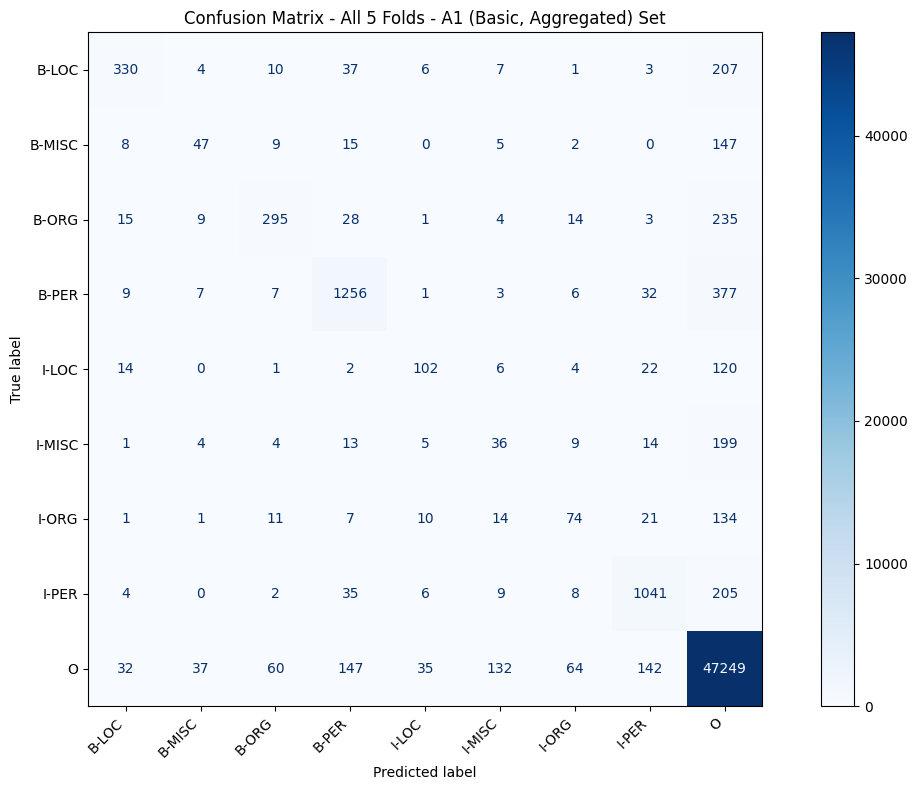

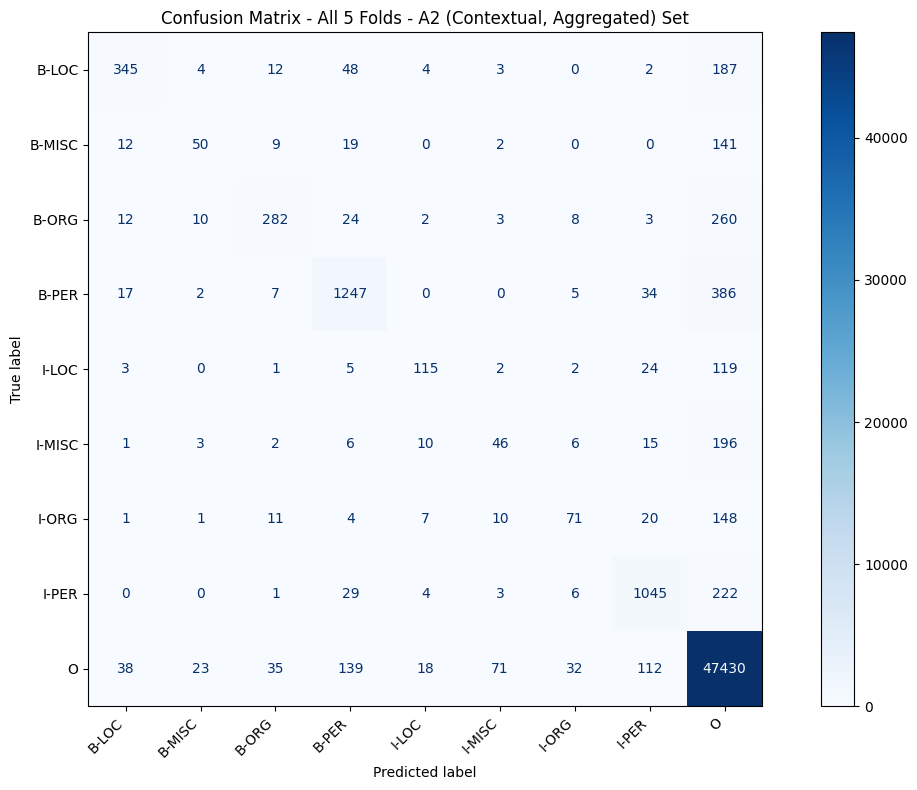


METHOD A COMPLETE: A2 selected as representative model



In [11]:
print("AGGREGATE RESULTS & SELECT BEST METHOD A\n" + "="*70)

# Calculate mean metrics for A1
mean_precision_A1 = np.mean(fold_scores_A1['precision'])
mean_recall_A1 = np.mean(fold_scores_A1['recall'])
mean_f1_A1 = np.mean(fold_scores_A1['f1'])
std_f1_A1 = np.std(fold_scores_A1['f1'])

# Calculate mean metrics for A2
mean_precision_A2 = np.mean(fold_scores_A2['precision'])
mean_recall_A2 = np.mean(fold_scores_A2['recall'])
mean_f1_A2 = np.mean(fold_scores_A2['f1'])
std_f1_A2 = np.std(fold_scores_A2['f1'])

# Compare A1 vs A2
f1_diff = mean_f1_A2 - mean_f1_A1
f1_threshold = 0.001

print("\n" + "="*70)
print("FOLD-BY-FOLD RESULTS")
print("="*70)

# Display per-fold results
results_data = []
for fold_idx in range(K_FOLDS):
    results_data.append({
        'Fold': fold_idx + 1,
        'A1 F1': f"{fold_scores_A1['f1'][fold_idx]:.4f}",
        'A2 F1': f"{fold_scores_A2['f1'][fold_idx]:.4f}",
        'Diff': f"{fold_scores_A2['f1'][fold_idx] - fold_scores_A1['f1'][fold_idx]:.4f}",
        'Winner': 'A2' if fold_scores_A2['f1'][fold_idx] > fold_scores_A1['f1'][fold_idx] else 'A1'
    })

results_df = pd.DataFrame(results_data)
print("\n", results_df.to_string(index=False))

print("\n" + "="*70)
print("AVERAGE METRICS ACROSS 5 FOLDS")
print("="*70)

# Create summary table
summary_data = {
    'Model': ['A1 (Basic)', 'A2 (Contextual)'],
    'Precision': [f"{mean_precision_A1:.4f}", f"{mean_precision_A2:.4f}"],
    'Recall': [f"{mean_recall_A1:.4f}", f"{mean_recall_A2:.4f}"],
    'F1-Score': [f"{mean_f1_A1:.4f} ± {std_f1_A1:.4f}", f"{mean_f1_A2:.4f} ± {std_f1_A2:.4f}"]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Decision logic
print("\n" + "="*70)
print("DECISION: SELECT BEST METHOD A")
print("="*70)

print(f"\nF1 Difference (A2 - A1): {f1_diff:.6f}")
print(f"Threshold: {f1_threshold}")

if abs(f1_diff) <= f1_threshold:
    best_A = 'A1'
    reason = f"Difference {abs(f1_diff):.6f} ≤ threshold {f1_threshold} -> Choose simpler model (A1)"
else:
    if f1_diff > 0:
        best_A = 'A2'
        reason = f"A2 better by {f1_diff:.6f} > threshold {f1_threshold}"
    else:
        best_A = 'A1'
        reason = f"A1 better by {abs(f1_diff):.6f} > threshold {f1_threshold}"

print(f"\nSELECTED: {best_A} (Mean F1: {max(mean_f1_A1, mean_f1_A2):.4f})")
print(f"  Reason: {reason}")

# PLOT CONFUSION MATRICES (AGGREGATED - ALL 5 FOLDS)
print(f"\n{'='*70}")
print("PLOTTING CONFUSION MATRICES (ALL 5 FOLDS - Aggregated)")
print(f"{'='*70}\n")

# Concatenate predictions from all 5 folds
y_val_A1_all = []
y_pred_A1_all = []
y_val_A2_all = []
y_pred_A2_all = []

for fold_idx in range(K_FOLDS):
    fold_predictions = all_fold_predictions[fold_idx]
    y_val_A1_all.extend(fold_predictions['y_val_A1'])
    y_pred_A1_all.extend(fold_predictions['y_pred_A1'])
    y_val_A2_all.extend(fold_predictions['y_val_A2'])
    y_pred_A2_all.extend(fold_predictions['y_pred_A2'])

# Plot confusion matrix for A1 (aggregated)
plot_confusion_matrix(y_val_A1_all, y_pred_A1_all, set_name="All 5 Folds - A1 (Basic, Aggregated)")

# Plot confusion matrix for A2 (aggregated)
plot_confusion_matrix(y_val_A2_all, y_pred_A2_all, set_name="All 5 Folds - A2 (Contextual, Aggregated)")

# Store best Model A for later comparison with Method B & C
best_method_A = best_A
best_scores_A = {
    'precision': mean_precision_A2 if best_A == 'A2' else mean_precision_A1,
    'recall': mean_recall_A2 if best_A == 'A2' else mean_recall_A1,
    'f1': mean_f1_A2 if best_A == 'A2' else mean_f1_A1,
    'std_f1': std_f1_A2 if best_A == 'A2' else std_f1_A1
}

print(f"\n{'='*70}")
print(f"METHOD A COMPLETE: {best_A} selected as representative model")
print(f"{'='*70}\n")

Method B: Statistical Series (HMM)

In [12]:
import math
import numpy as np
from collections import Counter, defaultdict

print("METHOD B - Statistical Series (HMM)\n" + "="*70)


def unk_signature(word):
    """Map unseen / rare words to a generic unknown token class."""
    if word == '_MENTION_':
        return '<UNK_MENTION>'
    if word == '_URL_':
        return '<UNK_URL>'
    if word == '_HASHTAG_':
        return '<UNK_HASHTAG>'
    if word.isdigit():
        return '<UNK_NUM>'

    punct_chars = set(".,!?;:-()[]{}'\"/\\&%$#@+=*`~^_|<>")
    if word and all(ch in punct_chars for ch in word):
        return '<UNK_PUNCT>'
    if word.isupper():
        return '<UNK_ALLCAPS>'
    if len(word) > 0 and word[0].isupper():
        return '<UNK_INITCAP>'
    if any(ch.isdigit() for ch in word):
        return '<UNK_ALNUM>'
    if word.islower():
        return '<UNK_LOWER>'
    return '<UNK_MISC>'


def valid_bio_transition(prev_tag, curr_tag):
    """Disallow illegal BIO transitions such as O -> I-PER."""
    if curr_tag.startswith('I-'):
        curr_type = curr_tag[2:]
        if prev_tag in ('<START>', 'O'):
            return False
        if prev_tag.startswith('B-') or prev_tag.startswith('I-'):
            return prev_tag[2:] == curr_type
        return False
    return True


def bio_to_entities(tags):
    """Convert BIO sequence into entity spans for exact-match entity scoring."""
    entities = set()
    start = None
    ent_type = None

    for i, tag in enumerate(tags + ['O']):
        if tag.startswith('B-'):
            if start is not None:
                entities.add((ent_type, start, i - 1))
            start = i
            ent_type = tag[2:]
        elif tag.startswith('I-'):
            current_type = tag[2:]
            if start is None or ent_type != current_type:
                if start is not None:
                    entities.add((ent_type, start, i - 1))
                start = i
                ent_type = current_type
        else:
            if start is not None:
                entities.add((ent_type, start, i - 1))
                start = None
                ent_type = None

    return entities


class HMMNER:
    """
    Hidden Markov Model for NER with:
    - transition probabilities between BIO tags
    - emission probabilities from tags to tokens
    - Laplace smoothing
    - rare/unseen word handling with unknown-word signatures
    - Viterbi decoding in log-space
    """

    def __init__(self, alpha_trans=0.5, alpha_emit=0.01, rare_threshold=1, use_bio_constraints=True):
        self.alpha_trans = alpha_trans
        self.alpha_emit = alpha_emit
        self.rare_threshold = rare_threshold
        self.use_bio_constraints = use_bio_constraints

    def fit(self, token_sequences, tag_sequences):
        self.tags_ = sorted({tag for seq in tag_sequences for tag in seq})
        self.word_freq_ = Counter(tok for seq in token_sequences for tok in seq)

        emit_counts = {tag: Counter() for tag in self.tags_}
        trans_counts = defaultdict(Counter)

        for tokens, tags in zip(token_sequences, tag_sequences):
            prev = '<START>'
            for tok, tag in zip(tokens, tags):
                obs = tok if self.word_freq_[tok] > self.rare_threshold else unk_signature(tok)
                emit_counts[tag][obs] += 1
                trans_counts[prev][tag] += 1
                prev = tag
            trans_counts[prev]['<END>'] += 1

        self.emit_counts_ = emit_counts
        self.trans_counts_ = trans_counts

        emission_vocab = set()
        for counts in emit_counts.values():
            emission_vocab.update(counts.keys())
        emission_vocab.update({
            '<UNK_MENTION>', '<UNK_URL>', '<UNK_HASHTAG>', '<UNK_NUM>', '<UNK_PUNCT>',
            '<UNK_ALLCAPS>', '<UNK_INITCAP>', '<UNK_ALNUM>', '<UNK_LOWER>', '<UNK_MISC>'
        })
        self.emission_vocab_ = sorted(emission_vocab)
        self.tag_to_idx_ = {tag: i for i, tag in enumerate(self.tags_)}

        m = len(self.tags_)
        V = len(self.emission_vocab_)

        self.log_start_ = np.full(m, -np.inf)
        self.log_trans_ = np.full((m, m), -np.inf)
        self.log_end_ = np.full(m, -np.inf)
        self.log_emit_ = {tag: {} for tag in self.tags_}

        # Start probabilities
        start_total = sum(trans_counts['<START>'].values())
        for j, tag in enumerate(self.tags_):
            if self.use_bio_constraints and not valid_bio_transition('<START>', tag):
                continue
            self.log_start_[j] = math.log(
                (trans_counts['<START>'][tag] + self.alpha_trans) /
                (start_total + self.alpha_trans * m)
            )

        # Transition probabilities
        for i, prev in enumerate(self.tags_):
            total_to_tags = sum(trans_counts[prev][t] for t in self.tags_)
            for j, curr in enumerate(self.tags_):
                if self.use_bio_constraints and not valid_bio_transition(prev, curr):
                    continue
                self.log_trans_[i, j] = math.log(
                    (trans_counts[prev][curr] + self.alpha_trans) /
                    (total_to_tags + self.alpha_trans * m)
                )

            total_all = total_to_tags + trans_counts[prev]['<END>']
            self.log_end_[i] = math.log(
                (trans_counts[prev]['<END>'] + self.alpha_trans) /
                (total_all + self.alpha_trans * (m + 1))
            )

        # Emission probabilities
        for tag in self.tags_:
            total = sum(emit_counts[tag].values())
            denom = total + self.alpha_emit * V
            for obs in self.emission_vocab_:
                self.log_emit_[tag][obs] = math.log(
                    (emit_counts[tag][obs] + self.alpha_emit) / denom
                )

        return self

    def _obs(self, token):
        if self.word_freq_.get(token, 0) > self.rare_threshold:
            return token
        return unk_signature(token)

    def predict_one(self, tokens):
        n = len(tokens)
        m = len(self.tags_)
        if n == 0:
            return []

        dp = np.full((n, m), -np.inf)
        back = np.zeros((n, m), dtype=int)

        obs0 = self._obs(tokens[0])
        emit0 = np.array([self.log_emit_[tag].get(obs0, -1e12) for tag in self.tags_])
        dp[0] = self.log_start_ + emit0

        for t in range(1, n):
            obs = self._obs(tokens[t])
            emit = np.array([self.log_emit_[tag].get(obs, -1e12) for tag in self.tags_])
            scores = dp[t - 1][:, None] + self.log_trans_
            back[t] = np.argmax(scores, axis=0)
            dp[t] = scores[back[t], np.arange(m)] + emit

        last_scores = dp[-1] + self.log_end_
        best = int(np.argmax(last_scores))
        path = [best]

        for t in range(n - 1, 0, -1):
            best = int(back[t, best])
            path.append(best)
        path.reverse()

        return [self.tags_[i] for i in path]

    def predict(self, token_sequences):
        return [self.predict_one(seq) for seq in token_sequences]


print("HMM helpers ready.")


METHOD B - Statistical Series (HMM)
HMM helpers ready.



METHOD B - 5-FOLD CROSS-VALIDATION

FOLD 1 / 5

Evaluation Results for Fold 1 - Method B Set
----------------------------------------------------------------------
Precision (Micro): 0.6255
Recall (Micro):    0.5150
F1-Score (Micro):  0.5649

Classification Report:
              precision    recall  f1-score   support

         LOC       0.66      0.35      0.46       117
        MISC       0.48      0.24      0.32        41
         ORG       0.67      0.45      0.53       112
         PER       0.62      0.63      0.62       330

   micro avg       0.63      0.52      0.56       600
   macro avg       0.61      0.42      0.49       600
weighted avg       0.63      0.52      0.55       600



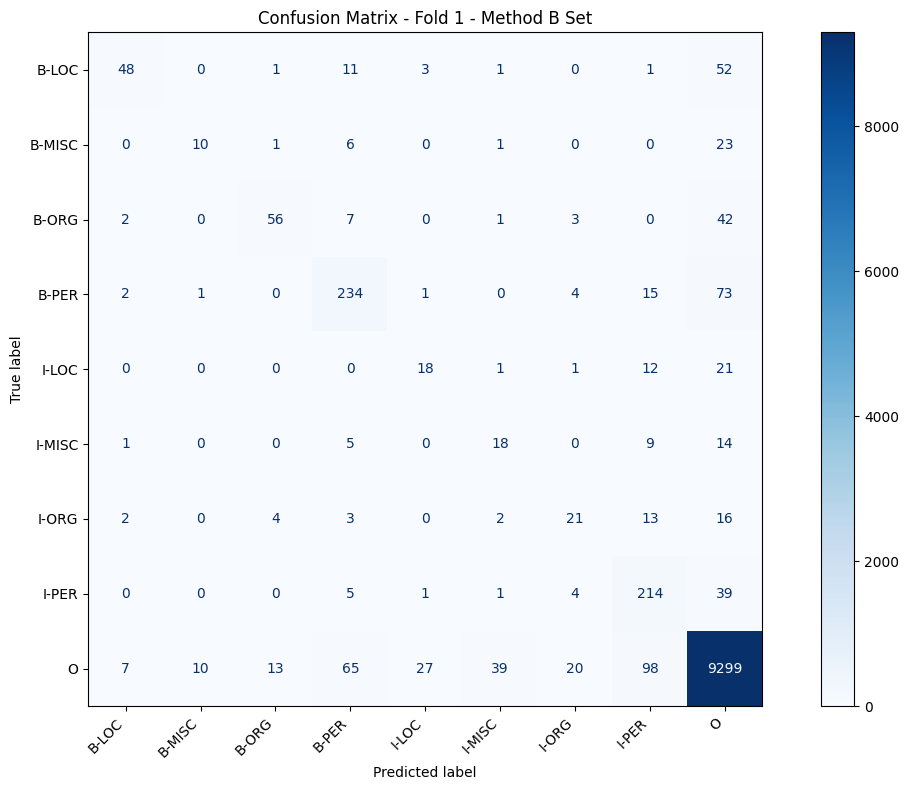


FOLD 2 / 5

Evaluation Results for Fold 2 - Method B Set
----------------------------------------------------------------------
Precision (Micro): 0.5927
Recall (Micro):    0.4530
F1-Score (Micro):  0.5135

Classification Report:
              precision    recall  f1-score   support

         LOC       0.72      0.41      0.53       114
        MISC       0.22      0.11      0.15        55
         ORG       0.71      0.35      0.46       139
         PER       0.57      0.57      0.57       341

   micro avg       0.59      0.45      0.51       649
   macro avg       0.56      0.36      0.43       649
weighted avg       0.60      0.45      0.50       649


FOLD 3 / 5

Evaluation Results for Fold 3 - Method B Set
----------------------------------------------------------------------
Precision (Micro): 0.6594
Recall (Micro):    0.5286
F1-Score (Micro):  0.5868

Classification Report:
              precision    recall  f1-score   support

         LOC       0.76      0.39      0.52     

In [13]:
print("\nMETHOD B - 5-FOLD CROSS-VALIDATION\n" + "="*70)

# Reset storage in case you rerun the cell
fold_scores_B = {'precision': [], 'recall': [], 'f1': []}
all_fold_predictions_B = {}

# Tuned settings from my run on your uploaded files
BEST_ALPHA_TRANS = 0.5
BEST_ALPHA_EMIT = 0.01
BEST_RARE_THRESHOLD = 1

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {K_FOLDS}")
    print(f"{'='*70}")

    train_df = sequences_df.iloc[train_idx].reset_index(drop=True)
    val_df = sequences_df.iloc[val_idx].reset_index(drop=True)

    X_train = train_df['tokens'].tolist()
    y_train = train_df['tags'].tolist()
    X_val = val_df['tokens'].tolist()
    y_val = val_df['tags'].tolist()

    hmm = HMMNER(
        alpha_trans=BEST_ALPHA_TRANS,
        alpha_emit=BEST_ALPHA_EMIT,
        rare_threshold=BEST_RARE_THRESHOLD,
        use_bio_constraints=True
    )
    hmm.fit(X_train, y_train)
    y_pred = hmm.predict(X_val)

    best_models_per_fold['B'].append(hmm)

    all_fold_predictions_B[fold_idx] = {
        'y_val_B': y_val,
        'y_pred_B': y_pred
    }

    metrics_B = evaluate_ner(y_val, y_pred, set_name=f"Fold {fold_idx + 1} - Method B")
    fold_scores_B['precision'].append(metrics_B['precision'])
    fold_scores_B['recall'].append(metrics_B['recall'])
    fold_scores_B['f1'].append(metrics_B['f1'])

    # Optional: show confusion matrix only for first fold to keep notebook shorter
    if fold_idx == 0:
        plot_confusion_matrix(y_val, y_pred, set_name=f"Fold {fold_idx + 1} - Method B")

print("\nMethod B cross-validation finished.")

In [14]:
print("AGGREGATE RESULTS & SELECT METHOD B\n" + "="*70)

mean_precision_B = np.mean(fold_scores_B['precision'])
mean_recall_B = np.mean(fold_scores_B['recall'])
mean_f1_B = np.mean(fold_scores_B['f1'])
std_f1_B = np.std(fold_scores_B['f1'])

results_data_B = []
for fold_idx in range(K_FOLDS):
    results_data_B.append({
        'Fold': fold_idx + 1,
        'Precision': f"{fold_scores_B['precision'][fold_idx]:.4f}",
        'Recall': f"{fold_scores_B['recall'][fold_idx]:.4f}",
        'F1': f"{fold_scores_B['f1'][fold_idx]:.4f}"
    })

results_df_B = pd.DataFrame(results_data_B)
display(results_df_B)

print("\n" + "="*70)
print("METHOD B SUMMARY")
print("="*70)
print(f"Mean Precision: {mean_precision_B:.4f}")
print(f"Mean Recall:    {mean_recall_B:.4f}")
print(f"Mean F1:        {mean_f1_B:.4f}")
print(f"Std F1:         {std_f1_B:.4f}")
print(f"Transition smoothing (alpha_trans): {BEST_ALPHA_TRANS}")
print(f"Emission smoothing (alpha_emit):    {BEST_ALPHA_EMIT}")
print(f"Rare-word threshold:                {BEST_RARE_THRESHOLD}")

AGGREGATE RESULTS & SELECT METHOD B


,Fold,Precision,Recall,F1
0,1,0.6255,0.5150,0.5649
1,2,0.5927,0.4530,0.5135
2,3,0.6594,0.5286,0.5868
3,4,0.6268,0.4943,0.5527
4,5,0.6187,0.4915,0.5478



METHOD B SUMMARY
Mean Precision: 0.6246
Mean Recall:    0.4965
Mean F1:        0.5532
Std F1:         0.0239
Transition smoothing (alpha_trans): 0.5
Emission smoothing (alpha_emit):    0.01
Rare-word threshold:                1


METHOD C: Bi-LSTM + CRF Approach (PyTorch)

In [15]:
print("METHOD C - Bi LSTM + CRF Approach (Pytorch)\n" + "="*70)

# Install torchcrf
try:
    from TorchCRF import CRF
except ImportError:
    print("Installing torchcrf")
    %pip install TorchCRF
    from TorchCRF import CRF

# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np
import urllib.request
import os

# SET SEED FOR REPRODUCIBILITY
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

#DEVICE CONFIGURATION
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

#BUILD VOCABULARY FROM SEQUENCES_DF
print("\n" + "-"*70)
print("BUILDING VOCABULARY\n" + "-"*70)

# Special tokens
PAD_TOKEN = "<PAD>" #Padding
UNK_TOKEN = "<UNK>" #Unknown
PAD_IDX = 0
UNK_IDX = 1

# BUILD TOKEN VOCABULARY (token -> id)
token2id = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
#Example
#Sentence A: [2, 3, 1, 0, 0, 0] (She is [UNK] [PAD] [PAD] [PAD]) Sentence B: [2, 4, 0, 0, 0, 0] (She beautiful [PAD] [PAD] [PAD] [PAD])
#--> Vocabulary: {PAD:0, UNK:1, She:2, is:3, beautiful:4}
#--> len(token2id) = 5 (PAD, UNK, She, is, beautiful) - 2 (PAD, UNK) = 3 word tokens
token_idx = 2
for tokens in sequences_df['tokens']:
    for token in tokens:
        if token not in token2id:
            token2id[token] = token_idx
            token_idx += 1

id2token = {v: k for k, v in token2id.items()}

print(f"Token vocabulary size: {len(token2id):,}")
print(f" - Special tokens: PAD(ID=0), UNK(ID=1)")
print(f" - Word tokens: {len(token2id) - 2:,}") #Always minus 2 because words like PAD or UNK are counted as having appeared and are not included in the count.

# BUILD CHARACTER VOCABULARY (char -> id)
char2id = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
char_idx = 2

all_chars = set()
for tokens in sequences_df['tokens']:
    for token in tokens:
        for char in token:
            all_chars.add(char)

for char in sorted(all_chars):
    if char not in char2id:
        char2id[char] = char_idx
        char_idx += 1

id2char = {v: k for k, v in char2id.items()}

print(f"Character vocabulary size: {len(char2id):,}")
print(f" - Special tokens: PAD(ID=0), UNK(ID=1)")
print(f" - Character tokens: {len(char2id) - 2:,}")

# BUILD TAG VOCABULARY (BIO tags --> id)
tag2id = {"<PAD>": 0}
tag_idx = 1

all_tags = set()
for tags in sequences_df['tags']:
    for tag in tags:
        all_tags.add(tag)

for tag in sorted(all_tags):
    if tag not in tag2id:
        tag2id[tag] = tag_idx
        tag_idx += 1

id2tag = {v: k for k, v in tag2id.items()}

print(f"Tag vocabulary size: {len(tag2id):,}")
print(f" Tags:{sorted(all_tags)}")

# Sanity Checks
print("\n" + "-"*70)
print("Sanity Checks:")
print("-"*70)

# Check: Vocabulary sizes
assert len(token2id) > 0, "Token vocabulary is empty!"
assert len(tag2id) > 0, "Tag vocabulary is empty!"
assert len(char2id) > 0, "Character vocabulary is empty!"
print("All vocabularies built successfully")

METHOD C - Bi LSTM + CRF Approach (Pytorch)
Device: mps

----------------------------------------------------------------------
BUILDING VOCABULARY
----------------------------------------------------------------------
Token vocabulary size: 10,416
 - Special tokens: PAD(ID=0), UNK(ID=1)
 - Word tokens: 10,414
Character vocabulary size: 92
 - Special tokens: PAD(ID=0), UNK(ID=1)
 - Character tokens: 90
Tag vocabulary size: 10
 Tags:['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']

----------------------------------------------------------------------
Sanity Checks:
----------------------------------------------------------------------
All vocabularies built successfully


In [16]:
# LOAD GloVe EMBEDDINGS (100D)
print("\n" + "-"*70)
print("Loading GloVe Embeddings (100D)")
print("-"*70)

EMBEDDING_DIM = 100
CHAR_EMBEDDING_DIM = 25
glove_file = "glove.twitter.27B/glove.twitter.27B.100d.txt"

# Check if GloVe file exists, if not download it
if not os.path.exists(glove_file):
    print(f"\nDownloading GloVe vectors")
    glove_zip = "glove.twitter.27B.zip"
    glove_url = "https://nlp.stanford.edu/data/glove.twitter.27B.zip"
    
    try:
        urllib.request.urlretrieve(glove_url, glove_zip)
        print(f"Downloaded {glove_zip}")
        
        # Extract
        import zipfile
        with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
            zip_ref.extractall("glove.twitter.27B")
        print(f"Extracted GloVe vectors")
        os.remove(glove_zip)
    except Exception as e:
        print(f"Could not download GloVe: {e}")
        print(f"Falling back to random embeddings")
        glove_file = None

# Initialize embedding matrix
embedding_matrix = np.zeros((len(token2id), EMBEDDING_DIM), dtype=np.float32)
embedding_matrix[PAD_IDX] = np.zeros(EMBEDDING_DIM, dtype=np.float32)  # PAD = zeros

# Load GloVe vectors if file exists
glove_found = 0

lower_to_ids = {}
for w, idx in token2id.items():
    low_w = w.lower()
    if low_w not in lower_to_ids:
        lower_to_ids[low_w] = []
    lower_to_ids[low_w].append(idx)

if glove_file and os.path.exists(glove_file):
    print(f"\nLoading GloVe vectors from {glove_file}...")
    with open(glove_file, 'r', encoding='utf-8', errors='ignore') as f:
        for line_idx, line in enumerate(f):
            values = line.split()
            if len(values) < EMBEDDING_DIM + 1:
                continue

            word = values[0]
            vector = np.array(values[1:EMBEDDING_DIM+1], dtype=np.float32)
            
            if word in lower_to_ids:
                for idx in lower_to_ids[word]:
                    # Only overwrite if that row doesn't already have an exact match (to prioritize uppercase/lowercase if available)
                    if np.sum(embedding_matrix[idx]) == 0:
                        embedding_matrix[idx] = vector
                        glove_found += 1
            
            # Show progress every 10k lines
            if (line_idx + 1) % 50000 == 0:
                print(f"  Processed: {line_idx + 1:,} words | Found: {glove_found:,}")
    
    print(f"GloVe loading complete")
    print(f"Total words matched: {glove_found:,} / {len(token2id):,}")

# Initialize remaining words (not in GloVe) with random vectors
random_init_count = 0
for idx in range(len(token2id)):
    if np.sum(embedding_matrix[idx]) == 0 and idx != PAD_IDX:
        # Word not found in GloVe, initialize randomly
        embedding_matrix[idx] = np.random.randn(EMBEDDING_DIM).astype(np.float32) * 0.1
        random_init_count += 1

print(f"\nEmbedding Matrix Summary:")
print(f"  Shape: {embedding_matrix.shape}")
print(f"  Words from GloVe: {glove_found:,}")
print(f"  Words randomly initialized: {random_init_count:,}")
print(f"  PAD (zeros): 1")
print(f"  Total: {len(token2id):,}")

'''
#Create Random Embedding Matrix random
print("\n" + "-"*70)
print("Initializing Embeddings")
print("-"*70)

EMBEDDING_DIM = 100 #direction of the word vector (Semantics and grammar of Words)
CHAR_EMBEDDING_DIM = 25 #direction of the character vector  (Form and structure of Character)

#Random embedding matrix for word tokens
embedding_matrix = np.random.randn(len(token2id), EMBEDDING_DIM).astype(np.float32) * 0.1 #Create a matrix of size V x D (Number of words x 100)

#Set PAD embeddings to zeros (no info)
embedding_matrix[PAD_IDX] = np.zeros(EMBEDDING_DIM, dtype=np.float32) #Compress all 100 numbers representing <PAD> to absolute zero. #numpy array

print (f"Word embedding matrix shape: {embedding_matrix.shape}")
print (f" - Vocab size: {embedding_matrix.shape[0]}")
print (f" - Embedding dimension: {embedding_matrix.shape[1]}")
print (f" - PAD embedding is all zeros: {(embedding_matrix[PAD_IDX] == 0).all()}") #Only returns True if all 100 values ​​are 0.
#print (f" - PAD embedding is all zeros: {torch.all(torch.from_numpy(embedding_matrix[PAD_IDX]) == 0).item()}") # PyTorch version of the same check #from numpy to torch tensor.
'''

#Configure Summary
print("\n" + "="*70)
print("METHOD C CONFIGURATION")
print("="*70)



config = {
    'device': str(device),
    'random_state': RANDOM_STATE,
    'token_vocab_size': len(token2id),
    'char_vocab_size': len(char2id),
    'tag_vocab_size': len(tag2id),
    'embedding_dim': EMBEDDING_DIM,
    'embedding_source': f'GloVe ({glove_found:,} matched) + Random ({random_init_count:,})',
    'char_embedding_dim': CHAR_EMBEDDING_DIM,
    'lstm_hidden_dim': 256, #Embedding is how to see individual words, while hidden_dim is how to remember and string those words together to understand the context --> Understand the meaning of a word within a sentence.
    'num_folds': K_FOLDS,
}

for key, value in config.items():
    print(f"  {key}: {value}")

# SANITY CHECK

print("\n" + "-"*70)
print("Sanity Checks:")
print("-"*70)

# Check 1: Embedding matrix
assert embedding_matrix.shape == (len(token2id), EMBEDDING_DIM), "Embedding shape mismatch!"
print(f"Embedding shape correct: {embedding_matrix.shape}")

# Check 2: No NaN/Inf in embeddings
has_nan = np.isnan(embedding_matrix).any()
has_inf = np.isinf(embedding_matrix).any()
assert not has_nan, "Embedding contains NaN!"
assert not has_inf, "Embedding contains Inf!"
print("No NaN or Inf values in embeddings")

# Check 3: PAD embedding is all zeros
assert np.all(embedding_matrix[PAD_IDX] == 0), "PAD embedding is not zero!"
print("PAD embedding is all zeros")

# Check 4: UNK embedding is initialized
assert np.sum(np.abs(embedding_matrix[UNK_IDX])) > 0, "UNK embedding is zero!"
print("UNK embedding is initialized")

# Check 5: Token-to-ID mappings
assert PAD_TOKEN in token2id and token2id[PAD_TOKEN] == PAD_IDX, "PAD token mapping error!"
assert UNK_TOKEN in token2id and token2id[UNK_TOKEN] == UNK_IDX, "UNK token mapping error!"
print("Special tokens mapped correctly")

# Check 6: Fold splits exist
assert len(fold_splits) == K_FOLDS, "Fold splits count mismatch!"
total_seqs = sum(len(train_idx) + len(val_idx) for train_idx, val_idx in fold_splits)
assert total_seqs == len(sequences_df) * K_FOLDS, "Fold splits don't cover all sequences!"
print("Fold splits validated")

# Check 7: GloVe coverage statistics
glove_coverage = (glove_found / (len(token2id) - 2)) * 100  # Exclude PAD and UNK
print(f"\nGloVe Coverage: {glove_coverage:.1f}% ({glove_found:,} / {len(token2id) - 2:,} words)")


----------------------------------------------------------------------
Loading GloVe Embeddings (100D)
----------------------------------------------------------------------

Loading GloVe vectors from glove.twitter.27B/glove.twitter.27B.100d.txt...
  Processed: 50,000 words | Found: 7,707
  Processed: 100,000 words | Found: 8,437
  Processed: 150,000 words | Found: 8,733
  Processed: 200,000 words | Found: 8,901
  Processed: 250,000 words | Found: 9,009
  Processed: 300,000 words | Found: 9,081
  Processed: 350,000 words | Found: 9,148
  Processed: 400,000 words | Found: 9,205
  Processed: 450,000 words | Found: 9,253
  Processed: 500,000 words | Found: 9,294
  Processed: 550,000 words | Found: 9,319
  Processed: 600,000 words | Found: 9,347
  Processed: 650,000 words | Found: 9,365
  Processed: 700,000 words | Found: 9,380
  Processed: 750,000 words | Found: 9,396
  Processed: 800,000 words | Found: 9,411
  Processed: 850,000 words | Found: 9,424
  Processed: 900,000 words | Found: 

In [17]:
print("Dataset Class + DataLoader for BiLSTM-CRF\n" + "="*70)

#DEFINE NERDataset CLASS
class NERDataset(Dataset):
    """
    PyTorch Dataset for NER task.
    Converts token sequences and tag sequences into IDs and handles padding.
    
    Args:
        tokens_list: List of token sequences [[token1, token2, ...], ...]
        tags_list: List of tag sequences [[tag1, tag2, ...], ...]
        token2id: Dictionary mapping tokens to IDs
        tag2id: Dictionary mapping tags to IDs
        char2id: Dictionary mapping characters to IDs (for char-level features)
    
    Return:
    Input (a sequence):
        tokens: ['She', 'is', 'cool']
        tags:   ['B-PER', 'O', 'O']
  
    Output (từ __getitem__):
        {
            'token_ids': [42, 15, 8],          ← From token2id dictionary
            'char_ids': [[23,15], [9], [3,4,5]], ← From char2id (per character)
            'tag_ids': [1, 0, 0],              ← From tag2id dictionary
            'seq_len': 3                        ← Actual length of the sequence (before padding)
        }

    """
    def __init__(self, tokens_list, tags_list, token2id, tag2id, char2id):
        self.tokens_list = tokens_list
        self.tags_list = tags_list
        self.token2id = token2id
        self.tag2id = tag2id
        self.char2id = char2id
    
    def __len__(self):
       return len(self.tokens_list)

    def __getitem__(self, idx):
        """
        Returns:
            token_ids: Tensor of token IDs [seq_len]
            char_ids: Tensor of character IDs [seq_len, max_char_len]
            tag_ids: Tensor of tag IDs [seq_len]
            seq_len: Integer sequence length (before padding)
        """
        tokens = self.tokens_list[idx]
        tags = self.tags_list[idx]
        seq_len = len(tokens)

        #Convert tokens to IDs
        token_ids = []
        for token in tokens:
            token_id = self.token2id.get(token, self.token2id.get('<UNK>', UNK_IDX)) #Get the ID for the token, if not found use UNK ID
            token_ids.append(token_id)
        
        #Convert characters to IDs
        char_ids = []
        for token in tokens:
            char_seq = []
            for char in token:
                char_id = self.char2id.get(char, self.char2id.get('<UNK>', UNK_IDX)) #Get the ID for the character, if not found use UNK ID
                char_seq.append(char_id)
            char_ids.append(char_seq)
        
        #Convert tags to IDs
        tag_ids = []
        for tag in tags:
            tag_id = self.tag2id.get(tag, self.tag2id.get('<PAD>', PAD_IDX)) #Get the ID for the tag, if not found use PAD ID (since tags should always be in the vocab, this is just a fallback)
            tag_ids.append(tag_id)

        return {
            'token_ids': token_ids,
            'char_ids': char_ids,
            'tag_ids': tag_ids,
            'seq_len': seq_len
        } #This is a sample
    
print("NERDataset class defined successfully")

#DEFINE COLLATE FUNCTION FOR BATCHING AND PADDING
def collate_fn(batch):
    """
    Collate function for DataLoader.
    Pads sequences in a batch to the same length.
    
    Args:
        batch: List of samples from NERDataset
    
    Returns:
        Dictionary with batched tensors:
            - token_ids: [batch_size, max_seq_len]
            - char_ids: [batch_size, max_seq_len, max_char_len]
            - tag_ids: [batch_size, max_seq_len]
            - seq_lens: [batch_size] (original sequence lengths for masking)
            - attention_mask: [batch_size, max_seq_len] (1 for real tokens, 0 for PAD)
    """

    #Extract sequence
    token_ids_batch = [sample['token_ids'] for sample in batch]
    char_ids_batch = [sample['char_ids'] for sample in batch]
    tag_ids_batch = [sample['tag_ids'] for sample in batch]
    seq_lens_batch = [sample['seq_len'] for sample in batch]

    #Find max lengths
    max_seq_len = max(seq_lens_batch)
    max_char_len = max(max(len(char_seq) for char_seq in char_ids)
                       for char_ids in char_ids_batch)
    
    #Pad token sequences
    token_ids_padded = []
    for token_ids in token_ids_batch:
        padded = token_ids + [PAD_IDX] * (max_seq_len - len(token_ids)) #PAD = 0
        token_ids_padded.append(padded)

    #Pad character sequences
    char_ids_padded = []
    for char_ids in char_ids_batch:
        char_seq_padded = []
        for char_seq in char_ids:
            #Pad individual character sequences to max_char_len
            padded_char_seq = char_seq + [PAD_IDX] * (max_char_len - len(char_seq))
            char_seq_padded.append(padded_char_seq)
        
        # Pad position in word sequences to max_seq_len
        while len(char_seq_padded) < max_seq_len:
            char_seq_padded.append([PAD_IDX] * max_char_len) #PAD token character sequence
        
        char_ids_padded.append(char_seq_padded)
    
    #Pad tag sequences
    tag_ids_padded = []
    for tag_ids in tag_ids_batch:
        padded = tag_ids + [PAD_IDX] * (max_seq_len - len(tag_ids)) #PAD = PAD_IDX
        tag_ids_padded.append(padded)

    #Create attention mask (only have 1 for real tokens, 0 for PAD)
    attention_mask = []
    for seq_len in seq_lens_batch:
        mask = [1] * seq_len + [0] * (max_seq_len - seq_len)
        attention_mask.append(mask)
    
    #Covert to tensors
    token_ids_tensor = torch.tensor(token_ids_padded, dtype=torch.long)
    char_ids_tensor = torch.tensor(char_ids_padded, dtype=torch.long)
    tag_ids_tensor = torch.tensor(tag_ids_padded, dtype=torch.long)
    attention_mask_tensor = torch.tensor(attention_mask, dtype=torch.long)
    seq_lens_tensor = torch.tensor(seq_lens_batch, dtype=torch.long)

    return {
        'token_ids': token_ids_tensor,
        'char_ids': char_ids_tensor,
        'tag_ids': tag_ids_tensor,
        'attention_mask': attention_mask_tensor,
        'seq_lens': seq_lens_tensor
    }

print("Collate function defined successfully")

#CREATE DATALOADERS FOR ALL 5 FOLDS
print("\n" + "-" * 70)
print("Creating Datasets and DataLoaders for all 5 folds")
print("-"* 70 + "\n")

fold_dataloaders = {}
BATCH_SIZE = 128
NUM_WORKERS = 0

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits): #enumerate(fold_splits) have item like (0 - index of fold, ([1, 2, 3] - train indices, [4, 5] - validation indices))
    print (f"Fold {fold_idx + 1}/{K_FOLDS}:")

    #Get train/val data for this fold
    train_df = sequences_df.iloc[train_idx].reset_index(drop=True)
    val_df = sequences_df.iloc[val_idx].reset_index(drop=True)

    #Create datasets
    train_dataset = NERDataset(
        train_df['tokens'].tolist(),
        train_df['tags'].tolist(),
        token2id,
        tag2id,
        char2id
    )

    val_dataset = NERDataset(
        val_df['tokens'].tolist(),
        val_df['tags'].tolist(),
        token2id,
        tag2id,
        char2id
    )

    #Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size = BATCH_SIZE,
        shuffle = True,
        collate_fn = collate_fn,
        num_workers = NUM_WORKERS
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size = BATCH_SIZE,
        shuffle = False,
        collate_fn = collate_fn,
        num_workers = NUM_WORKERS
    )

    fold_dataloaders[fold_idx] = {
        'train': train_loader,
        'val': val_loader,
        'train_size': len(train_dataset),
        'val_size': len(val_dataset)
    }

    print(f"Train batches: {len(train_loader)} size: {len(train_dataset)}")
    print(f"Val batches: {len(val_loader)} size: {len(val_dataset)}")

# SANITY CHECK
print("\n" + "-"*70)
print("Sanity Checks:")
print("-"*70)

# Check 1: DataLoaders created for all folds
assert len(fold_dataloaders) == K_FOLDS, "DataLoaders not created for all folds!"
print("DataLoaders created for all K folds")

# Check 2: Batch shapes and types
sample_batch = next(iter(fold_dataloaders[0]['train']))
assert 'token_ids' in sample_batch, "token_ids missing from batch!"
assert 'tag_ids' in sample_batch, "tag_ids missing from batch!"
assert 'attention_mask' in sample_batch, "attention_mask missing from batch!"
assert 'char_ids' in sample_batch, "char_ids missing from batch!"
print("All required keys in batch")

# Check 3: Tensor shapes
batch_size = sample_batch['token_ids'].shape[0]
max_seq_len = sample_batch['token_ids'].shape[1]
max_char_len = sample_batch['char_ids'].shape[2]

assert sample_batch['tag_ids'].shape == sample_batch['token_ids'].shape, \
    f"Tag tensor shape {sample_batch['tag_ids'].shape} != token shape {sample_batch['token_ids'].shape}"
assert sample_batch['attention_mask'].shape == sample_batch['token_ids'].shape, \
    f"Attention mask shape {sample_batch['attention_mask'].shape} != token shape"
print(f"Tensor shapes correct (batch_size={batch_size}, seq_len={max_seq_len}, char_len={max_char_len})")

# Check 4: Tensor types (must be Long/Int64 for CRF)
assert sample_batch['token_ids'].dtype == torch.long, "token_ids must be Long tensor!"
assert sample_batch['tag_ids'].dtype == torch.long, "tag_ids must be Long tensor!"
assert sample_batch['attention_mask'].dtype == torch.long, "attention_mask must be Long tensor!"
print("All tensors are Long type (compatible with CRF)")

# Check 5: PAD masking works correctly
assert (sample_batch['attention_mask'][:, -1] == 0).any(), \
    "Attention mask should have 0s for PAD positions"
print("Attention mask correctly masks PAD tokens")

# Check 6: Vocabulary coverage
for batch_idx, batch in enumerate(fold_dataloaders[0]['val']):
    token_ids = batch['token_ids']
    max_token_id = token_ids.max().item()
    assert max_token_id < len(token2id), \
        f"Token ID {max_token_id} exceeds vocab size {len(token2id)}"
    if batch_idx > 5:  # Just check first few batches for speed
        break
print("All token IDs within vocabulary bounds")

# Check 7: Fold data coverage
total_train = sum(fold_dataloaders[fold_idx]['train_size'] 
                  for fold_idx in range(K_FOLDS))
total_val = sum(fold_dataloaders[fold_idx]['val_size'] 
                for fold_idx in range(K_FOLDS))

print(f"\nTotal sequences covered:")
print(f"  - Training: {total_train:,}")
print(f"  - Validation: {total_val:,}")
print(f"  - Grand total: {total_train + total_val:,} (= 5 × {len(sequences_df):,})")

#DISPLAY SAMPLE BATCH
print("\n" + "-"*70)
print("Sample Batch (first sequence from Fold 1 training data):")
print("-"*70)

sample_batch = next(iter(fold_dataloaders[0]['train']))
seq_idx = 0

print(f"\nToken IDs:    {sample_batch['token_ids'][seq_idx].tolist()}")
print(f"Tag IDs:      {sample_batch['tag_ids'][seq_idx].tolist()}")
print(f"Seq length:   {sample_batch['seq_lens'][seq_idx].item()}")
print(f"Attention mask: {sample_batch['attention_mask'][seq_idx].tolist()}")

# Decode back to tokens/tags for verification
token_ids_list = sample_batch['token_ids'][seq_idx].tolist()
tag_ids_list = sample_batch['tag_ids'][seq_idx].tolist()
seq_len = sample_batch['seq_lens'][seq_idx].item()

tokens_decoded = [id2token.get(tid, '<UNK>') for tid in token_ids_list[:seq_len]]
tags_decoded = [id2tag.get(tid, '<PAD>') for tid in tag_ids_list[:seq_len]]

print(f"\nDecoded tokens: {tokens_decoded}")
print(f"Decoded tags:   {tags_decoded}")




Dataset Class + DataLoader for BiLSTM-CRF
NERDataset class defined successfully
Collate function defined successfully

----------------------------------------------------------------------
Creating Datasets and DataLoaders for all 5 folds
----------------------------------------------------------------------

Fold 1/5:
Train batches: 18 size: 2252
Val batches: 5 size: 563
Fold 2/5:
Train batches: 18 size: 2252
Val batches: 5 size: 563
Fold 3/5:
Train batches: 18 size: 2252
Val batches: 5 size: 563
Fold 4/5:
Train batches: 18 size: 2252
Val batches: 5 size: 563
Fold 5/5:
Train batches: 18 size: 2252
Val batches: 5 size: 563

----------------------------------------------------------------------
Sanity Checks:
----------------------------------------------------------------------
DataLoaders created for all K folds
All required keys in batch
Tensor shapes correct (batch_size=128, seq_len=54, char_len=15)
All tensors are Long type (compatible with CRF)
Attention mask correctly masks PAD 

In [18]:
print("VARIATION C1: BiLSTM-CRF with only WORD EMBEDDINGS\n" + "="*70)

HIDDEN_DIM = 256
CHAR_CONV_FILTERS = 100
CHAR_CONV_KERNEL = 3
EMBEDDING_DIM = 100
CHAR_EMBEDDING_DIM = 50

#DEFINE BiLSTM_C1 MODEL (WORD EMBEDDINGS ONLY)
class BiLSTM_C1(nn.Module):
    """
    Variant C1 (Word embeddings only)
    
    Flow:
    Input token_ids from cell of Dataset Class + DataLoader for BiLSTM-CRF 
    -> (this cell begins here) Word Embedding (Embedding Layer - GloVe 100D) 
    -> Bi-LSTM -> Linear -> CRF -> Output (Prediction)
    
    Args:
        vocab_size: Size of token vocabulary
        tag_size: Number of BIO tags
        embedding_dim: Dimension of word embeddings (GloVe 100D)
        hidden_dim: Hidden dimension of LSTM (256)
        embedding_matrix: Pre-trained GloVe embedding matrix
        num_layers: Number of LSTM layers (default: 2)
        dropout: Dropout rate (default: 0.4)
        bidirectional: Use bidirectional LSTM (default: True)
    """

    def __init__ (self, vocab_size, tag_size, embedding_dim, hidden_dim, embedding_matrix,
                  num_layers, dropout, bidirectional=True):
        super(BiLSTM_C1, self).__init__()

        self.vocab_size = vocab_size
        self.tag_size = tag_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        #Word Embedding layer (initialized with GloVe)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)

        # Load pre-trained embeddings (GloVe)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.data[PAD_IDX] = torch.zeros(embedding_dim) #Ensure PAD token is zeros
        
        #BiLSTM layer
        self.lstm = nn.LSTM(
            input_size = embedding_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0, #No dropout if only 1 layer
            bidirectional = bidirectional
        )

        #Linear layer for tag space
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.linear = nn.Linear(lstm_output_dim, tag_size)

        #CRF layer
        self.crf = CRF(tag_size, batch_first=True)

        # Dropout layer
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, token_ids, attention_mask, tag_ids=None, seq_lens=None):
        """
        Forward pass for BiLSTM_C1

        Args:
            token_ids: [batch_size, seq_len] Tensor of token IDs
            attention_mask: [batch_size, seq_len] Tensor (1 for real tokens, 0 for PAD)
            tag_ids: [batch_size, seq_len] Tensor of tag IDs (for training)
            seq_lens: [batch_size] - Original sequence lengths (for CRF)
        
        Returns:
            If tag_ids provided (training): loss (scalar)
            If tag_ids None (inference): predictions [batch_size, seq_len]
        """
        #Get word embeddings
        #Input: [batch_size, seq_len] -> Output: [batch_size, seq_len, embedding_dim]
        embeddings = self.embedding(token_ids)
        embeddings = self.dropout(embeddings)

        #Pack padded sequences
        packed_embedding = nn.utils.rnn.pack_padded_sequence(
            embeddings,
            lengths = seq_lens.cpu(), #Lengths on CPU for packing
            batch_first = True,
            enforce_sorted = False #Do not require sorted sequences
        )

        #Pass through BiLSTM
        #Input: Packed sequence -> Output: Packed sequence (with lstm_out features)
        packed_lstm_output, _ = self.lstm(packed_embedding)

        #Unpack sequences
        #Input: Packed sequence -> Output: [batch_size, seq_len, hidden_dim*2]
        lstm_output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_lstm_output, 
            batch_first=True
        )
        lstm_output = self.dropout(lstm_output)

        #Linear projection to tag space
        #Input: [batch_size, seq_len, hidden_dim*2] -> Output: [batch_size, seq_len, tag_size]
        emissions = self.linear(lstm_output)

        #CRF layer (training vs reasoning)
        if tag_ids is not None:
            #Training: Compute negative log-likelihood loss
            loss = -self.crf(emissions, tag_ids, mask=attention_mask.bool(), reduction='mean')
            return loss
        else:
            #Reasoning: get best tag sequence
            predictions = self.crf.decode(emissions, mask=attention_mask.bool())
            #Convert list of predictions to tensor for batch processing(pad to max_seq_len)
            max_len = max(len(p) for p in predictions)
            predictions_padded = []
            for pred in predictions:
                padded_pred = pred + [PAD_IDX] * (max_len - len(pred)) #PAD with PAD_IDX
                predictions_padded.append(padded_pred)
            predictions_tensor = torch.tensor(predictions_padded, dtype=torch.long, device=token_ids.device)
            return predictions_tensor
        
print("BiLSTM_C1 model defined (not trained yet) successfully")

VARIATION C1: BiLSTM-CRF with only WORD EMBEDDINGS
BiLSTM_C1 model defined (not trained yet) successfully


In [19]:
#TEST MODEL INSTANTIATION (JUST TEST FLOW FROM INPUT TO OUTPUT WITHOUT TRAINING)
print("\n" + "-"*70)
print("Testing BiLSTM_C1 instantiation")
print("-"*70)

#Create model instance
model_C1 = BiLSTM_C1(
    vocab_size = len(token2id),
    tag_size = len(tag2id),
    embedding_dim = EMBEDDING_DIM,
    hidden_dim = HIDDEN_DIM,
    embedding_matrix = embedding_matrix,
    num_layers = 2,
    dropout = 0.4,
    bidirectional = True
)

print(f"BiLSTM_C1 model created successfully")
print(f"\nModel Architecture:")
print(f"  Input vocab size: {len(token2id):,}")
print(f"  Output tag size: {len(tag2id):,}")
print(f"  Word embedding dim: {EMBEDDING_DIM}")
print(f"  LSTM hidden dim: {HIDDEN_DIM} (× 2 for bidirectional = {HIDDEN_DIM * 2})")
print(f"  LSTM layers: 2")
print(f"  Dropout: 0.4")
print(f"  Total parameters: {sum(p.numel() for p in model_C1.parameters()):,}")

#Calculatte trainable parameters
trainable_params = sum(p.numel() for p in model_C1.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

#TEST FORWARD PASS (TRAINING MODE)
print("\n" + "-"*70)
print("Testing BiLSTM_C1 forward pass (training mode)")
print("-"*70)

#Get a sample batch from fold 1 training data
sample_batch = next(iter(fold_dataloaders[0]['train']))

#Move batch to device
token_ids = sample_batch['token_ids'].to(device)
tag_ids = sample_batch['tag_ids'].to(device)
attention_mask = sample_batch['attention_mask'].to(device)
seq_lens = sample_batch['seq_lens'].to(device)

#Move model to device
model_C1 = model_C1.to(device)

#Forward pass (training mode)
with torch.no_grad():
    loss = model_C1(token_ids, attention_mask, tag_ids, seq_lens)

print(f"Forward pass successful (training mode)")
print(f"Batch size: {token_ids.shape[0]}")
print(f"Sequence length: {token_ids.shape[1]}")
print(f"Loss: {loss.item():.4f}")

#TEST FORWARD PASS (REASONING MODE)
print("\n" + "-"*70)
print("Testing BiLSTM_C1 forward pass (reasoning mode)")
print("-"*70)

#Forward pass (reasoning mode)
with torch.no_grad():
    predictions = model_C1(
        token_ids = token_ids,
        attention_mask = attention_mask,
        tag_ids = None, #No tags during reasoning
        seq_lens = seq_lens
    )

print(f"Forward pass successful (inference mode)")
print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions (first 5 tags): {predictions[0, :5].tolist()}")

# Decode predictions back to tag names
sample_pred_ids = predictions[0, :seq_lens[0].item()].cpu().tolist()
sample_pred_tags = [id2tag.get(tag_id, '<UNK>') for tag_id in sample_pred_ids]
sample_true_ids = tag_ids[0, :seq_lens[0].item()].cpu().tolist()
sample_true_tags = [id2tag.get(tag_id, '<UNK>') for tag_id in sample_true_ids]

print(f"\nSample sequence (first 5 tokens):")
print(f"  Predicted tags: {sample_pred_tags[:5]}")
print(f"  True tags:      {sample_true_tags[:5]}")


----------------------------------------------------------------------
Testing BiLSTM_C1 instantiation
----------------------------------------------------------------------
BiLSTM_C1 model created successfully

Model Architecture:
  Input vocab size: 10,416
  Output tag size: 10
  Word embedding dim: 100
  LSTM hidden dim: 256 (× 2 for bidirectional = 512)
  LSTM layers: 2
  Dropout: 0.4
  Total parameters: 3,356,994
Trainable parameters: 3,356,994

----------------------------------------------------------------------
Testing BiLSTM_C1 forward pass (training mode)
----------------------------------------------------------------------
Forward pass successful (training mode)
Batch size: 128
Sequence length: 40
Loss: 44.2624

----------------------------------------------------------------------
Testing BiLSTM_C1 forward pass (reasoning mode)
----------------------------------------------------------------------
Forward pass successful (inference mode)
Predictions shape: torch.Size([12

In [20]:
# STEP 5: Sanity Checks

print("\n" + "-"*70)
print("Sanity Checks:")
print("-"*70)

# Check 1: Model layers
assert hasattr(model_C1, 'embedding'), "Embedding layer missing!"
assert hasattr(model_C1, 'lstm'), "LSTM layer missing!"
assert hasattr(model_C1, 'linear'), "Linear layer missing!"
assert hasattr(model_C1, 'crf'), "CRF layer missing!"
print("All required layers present")

# Check 2: Model parameters
total_params = sum(p.numel() for p in model_C1.parameters())
assert total_params > 0, "Model has no parameters!"
print(f"Model has {total_params:,} parameters")

# Check 3: Loss is scalar and positive (for training)
assert loss.dim() == 0, "Loss is not scalar!"
assert loss.item() > 0, "Loss is not positive!"
print(f"Loss is scalar and positive: {loss.item():.4f}")

# Check 4: Predictions have correct shape
assert predictions.shape[0] == token_ids.shape[0], "Batch size mismatch in predictions!"
assert predictions.shape[1] == token_ids.shape[1], "Sequence length mismatch in predictions!"
print(f"Predictions have correct shape: {predictions.shape}")

# Check 5: Predictions are valid tag IDs
max_pred_id = predictions.max().item()
min_pred_id = predictions.min().item()
assert 0 <= min_pred_id < len(tag2id), f"Invalid min prediction ID: {min_pred_id}"
assert 0 <= max_pred_id < len(tag2id), f"Invalid max prediction ID: {max_pred_id}"
print(f"All predictions are valid tag IDs (min={min_pred_id}, max={max_pred_id})")

# Check 6: Embedding vectors from GloVe are loaded
embedding_norm = torch.norm(model_C1.embedding.weight[1:100], dim=1).mean().item()
assert embedding_norm > 0.1, "Embedding vectors may not be loaded properly!"
print(f"GloVe embeddings loaded (avg norm: {embedding_norm:.4f})")

# Check 7: Model can be moved to different devices
model_on_cpu = model_C1.to('cpu')
predictions_cpu = model_on_cpu(token_ids.to('cpu'), attention_mask.to('cpu'), tag_ids=None, seq_lens=seq_lens)
assert predictions_cpu.device.type == 'cpu', "Model device mismatch!"
print(f"Model can be moved between devices")


----------------------------------------------------------------------
Sanity Checks:
----------------------------------------------------------------------
All required layers present
Model has 3,356,994 parameters
Loss is scalar and positive: 44.2624
Predictions have correct shape: torch.Size([128, 40])
All predictions are valid tag IDs (min=0, max=9)
GloVe embeddings loaded (avg norm: 5.4785)
Model can be moved between devices


In [21]:
print("VARIATION C2: BiLSTM_C2 MODEL DEFINITION (Word + Character Embeddings)\n" + "="*70)

"""
Flow:
Input from cell of Dataset Class + DataLoader for BiLSTM-CRF (token_ids + char_ids)
-> (this cell begins here) Word Embedding (Embedding Layer - GloVe 100D)  + Character CNN
-> Concatenate (Combine word vectors and character vectors into a single vector)
-> Bi-LSTM -> Linear -> CRF -> Output (Prediction)
"""

#BiLSTM_C2 MODEL (WORD AND CHAR EMBEDDINGS)
#Define Character CNN for character-level features
class CharacterCNN(nn.Module):
    """
    Character-level 1D-CNN to extract character-level features for each word.
    
    Process: char_ids -> char_embedding -> CNN -> max_pooling -> char_features
    
    Args:
        char_vocab_size: Size of character vocabulary
        char_embedding_dim: Dimension of character embeddings (25D)
        char_conv_filters: Number of filters for convolution (default: 100)
        char_conv_kernel: Kernel size for convolution (default: 3)
    """

    def __init__ (self, char_vocab_size, char_embedding_dim, char_conv_filters, char_conv_kernel): 
        #char_conv_kernel = 3: trigram; char_conv_filters = 100: number of different patterns we want to capture in the character sequences.
        super(CharacterCNN, self).__init__()

        self.char_vocab_size = char_vocab_size
        self.char_embedding_dim = char_embedding_dim
        self.char_conv_filters = char_conv_filters
        self.char_conv_kernel = char_conv_kernel

        #Character embedding layer
        # Input: [batch_size, seq_len, max_char_len] -> Output: [batch_size, seq_len, max_char_len, char_embedding_dim]
        self.char_embedding = nn.Embedding(char_vocab_size, char_embedding_dim, padding_idx=PAD_IDX)

        #One-Dimensional Convolution layer
        # Input: [batch_size * seq_len, char_embedding_dim, max_char_len] -> Output: [batch_size * seq_len, char_conv_filters, conv_seq_len]
        self.char_conv = nn.Conv1d(
            in_channels = char_embedding_dim,
            out_channels = char_conv_filters,
            kernel_size = char_conv_kernel,
            padding = (char_conv_kernel - 1) // 2 #Same padding to maintain sequence length
            #Add 0 padding on both sides of the input to ensure the output has the same length as the input when using a kernel size of 3.
            #Example: [H,A,N,O,I] -> if not adding padding, the convolution with kernel size 3 would only produce outputs for [H,A,N], [A,N,O], [N,O,I] -> A, N, O (length 3 instead of 5). 
            #With padding of 1 on each side, we get outputs for [PAD,H,A], [H,A,N], [A,N,O], [N,O,I], [O,I,PAD] (length 5).
        )

    def forward(self, char_ids):
        """
        Forward pass for Character CNN
        
        Args:
            char_ids: [batch_size, max_seq_len, max_char_len] - Character IDs
        
        Returns:
            char_features: [batch_size, max_seq_len, char_conv_filters] - Character embeddings
        """

        batch_size, max_seq_len, max_char_len = char_ids.shape

        #Reshape for embedding: [batch_size * seq_len, max_char_len]
        char_ids_reshaped = char_ids.view(-1, max_char_len)

        #Character embedding: [batch_size * seq_len, max_char_len, char_embedding_dim]
        char_embeddings = self.char_embedding(char_ids_reshaped)

         # Transpose for convolution: [batch_size * max_seq_len, char_embedding_dim, max_char_len]
        char_embeddings_transposed = char_embeddings.transpose(1, 2)
        
        # Apply convolution: [batch_size * max_seq_len, char_conv_filters, max_char_len]
        char_conv_output = self.char_conv(char_embeddings_transposed)
        char_conv_output = torch.relu(char_conv_output)
        
        # Max pooling over character dimension: [batch_size * max_seq_len, char_conv_filters]
        char_features = torch.max(char_conv_output, dim=2)[0]
        
        # Reshape back: [batch_size, max_seq_len, char_conv_filters]
        char_features = char_features.view(batch_size, max_seq_len, self.char_conv_filters)
        
        return char_features
    
print("CharacterCNN class defined")

#DEFINE BiLSTM_C2 MODEL (WORD + CHAR EMBEDDINGS)
class BiLSTM_C2(nn.Module):
    """
    Variant C2 (Word + Character embeddings)
    
    Flow:
    Input from cell of Dataset Class + DataLoader for BiLSTM-CRF 
    -> (this cell begins here) Word Embedding + Character CNN 
    -> Concatenate (Combine word vectors and character vectors into a single vector) 
    -> Bi-LSTM -> Linear -> CRF -> Output
    
    Args:
        vocab_size: Size of token vocabulary
        tag_size: Number of BIO tags
        embedding_dim: Dimension of word embeddings (GloVe 100D)
        char_vocab_size: Size of character vocabulary
        char_embedding_dim: Dimension of character embeddings (25D)
        hidden_dim: Hidden dimension of LSTM (256)
        embedding_matrix: Pre-trained GloVe embedding matrix
        char_conv_filters: Number of character CNN filters (default: 100)
        char_conv_kernel: Kernel size for character CNN (default: 3)
        num_layers: Number of LSTM layers (default: 2)
        dropout: Dropout rate (default: 0.4)
        bidirectional: Use bidirectional LSTM (default: True)
    """

    def __init__ (self, vocab_size, tag_size, embedding_dim, char_vocab_size, char_embedding_dim,
                 hidden_dim, embedding_matrix, char_conv_filters, char_conv_kernel,
                 num_layers, dropout, bidirectional=True):
        super(BiLSTM_C2, self).__init__()

        self.vocab_size = vocab_size
        self.tag_size = tag_size
        self.embedding_dim = embedding_dim
        self.char_vocab_size = char_vocab_size
        self.char_embedding_dim = char_embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.char_conv_filters = char_conv_filters

        #Word Embedding layer (initialized with GloVe)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.data[PAD_IDX] = torch.zeros(embedding_dim) #Ensure PAD token is zeros

        #Character CNN for character-level features
        self.char_cnn = CharacterCNN(
            char_vocab_size = char_vocab_size,
            char_embedding_dim = char_embedding_dim,
            char_conv_filters = char_conv_filters,
            char_conv_kernel = char_conv_kernel
        )

        #Combine word embedding and character features
        combined_embedding_dim = embedding_dim + char_conv_filters

        #BiLSTM layer
        self.lstm = nn.LSTM(
            input_size = combined_embedding_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0, #No dropout if only 1 layer
            bidirectional = bidirectional
        )

        #Linear layer for tag space
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.linear = nn.Linear(lstm_output_dim, tag_size)

        #CRF layer
        self.crf = CRF(tag_size, batch_first=True)

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, token_ids, char_ids, attention_mask, tag_ids=None, seq_lens=None):
        """
        Forward pass for BiLSTM_C2

        Args:
            token_ids: [batch_size, seq_len] Tensor of token IDs
            char_ids: [batch_size, seq_len, max_char_len] Tensor of character IDs
            attention_mask: [batch_size, seq_len] Tensor (1 for real tokens, 0 for PAD)
            tag_ids: [batch_size, seq_len] Tensor of tag IDs (for training)
            seq_lens: [batch_size] - Original sequence lengths (for CRF)
        
        Returns:
            If tag_ids provided (training): loss (scalar)
            If tag_ids None (reasoning): predictions [batch_size, seq_len]
        """

        #Get word embeddings
        #Input: [batch_size, seq_len] -> Output: [batch_size, seq_len, embedding_dim]
        word_embeddings = self.embedding(token_ids)
        word_embeddings = self.dropout(word_embeddings)

        #Get character embeddings from CNN
        # [batch_size, seq_len, max_char_len] → [batch_size, seq_len, char_conv_filters]
        char_embeddings = self.char_cnn(char_ids)
        char_embeddings = self.dropout(char_embeddings)

        #Combine word and character embeddings
        #Input: word_embeddings [batch_size, seq_len, embedding_dim], char_embeddings [batch_size, seq_len, char_conv_filters]
        #Output: combined_embeddings [batch_size, seq_len, embedding_dim + char_conv_filters]
        combined_embeddings = torch.cat([word_embeddings, char_embeddings], dim=2)

        #Pack padded sequences
        packed_embedding = nn.utils.rnn.pack_padded_sequence(
            combined_embeddings,
            lengths = seq_lens.cpu(), #Lengths on CPU for packing
            batch_first = True,
            enforce_sorted = False #Do not require sorted sequences
        )

        #Pass through BiLSTM
        #Input: Packed sequence -> Output: Packed sequence (with lstm_out features)
        packed_lstm_output, _ = self.lstm(packed_embedding)

        #Unpack sequences
        #Input: Packed sequence -> Output: [batch_size, seq_len, hidden_dim*2]
        lstm_output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_lstm_output,
            batch_first=True
        )
        lstm_output = self.dropout(lstm_output)

        #Linear projection to tag space
        #Input: [batch_size, seq_len, hidden_dim*2] -> Output: [batch_size, seq_len, tag_size]
        emissions = self.linear(lstm_output)

        #CRF layer (training vs reasoning)
        if tag_ids is not None:
            #Training: Compute negative log-likelihood loss
            loss = -self.crf(emissions, tag_ids, mask=attention_mask.bool(), reduction='mean')
            return loss
        else:
            #Reasoning: get best tag sequence
            predictions = self.crf.decode(emissions, mask=attention_mask.bool())
            #Convert list of predictions to tensor for batch processing(pad to max_seq_len)
            max_len = max(len(p) for p in predictions)
            predictions_padded = []
            for pred in predictions:
                padded_pred = pred + [PAD_IDX] * (max_len - len(pred)) #PAD with PAD_IDX
                predictions_padded.append(padded_pred)
            predictions_tensor = torch.tensor(predictions_padded, dtype=torch.long, device=token_ids.device)
            return predictions_tensor

print("BiLSTM_C2 model defined (not trained yet) successfully")

VARIATION C2: BiLSTM_C2 MODEL DEFINITION (Word + Character Embeddings)
CharacterCNN class defined
BiLSTM_C2 model defined (not trained yet) successfully


In [22]:
#TEST MODEL INSTANTIATION (JUST TEST FLOW FROM INPUT TO OUTPUT WITHOUT TRAINING)
print("\n" + "-"*70)
print("Testing BiLSTM_C2 instantiation")
print("-"*70)

#Create model instance
model_C2 = BiLSTM_C2(
    vocab_size = len(token2id),
    tag_size = len(tag2id),
    embedding_dim = EMBEDDING_DIM,
    char_vocab_size = len(char2id),
    char_embedding_dim = CHAR_EMBEDDING_DIM,
    hidden_dim = HIDDEN_DIM,
    embedding_matrix = embedding_matrix,
    char_conv_filters = CHAR_CONV_FILTERS,
    char_conv_kernel = CHAR_CONV_KERNEL,
    num_layers = 2,
    dropout = 0.4,
    bidirectional = True
)

print(f"BiLSTM_C2 model created successfully")
print(f"\nModel Architecture:")
print(f"  Input vocab size: {len(token2id):,}")
print(f"  Character vocab size: {len(char2id):,}")
print(f"  Output tag size: {len(tag2id):,}")
print(f"  Word embedding dim: {EMBEDDING_DIM}")
print(f"  Character CNN: {CHAR_CONV_FILTERS} filters, kernel {CHAR_CONV_KERNEL}")
print(f"  Combined embedding: {EMBEDDING_DIM + CHAR_CONV_FILTERS}")
print(f"  LSTM hidden dim: {HIDDEN_DIM} (× 2 for bidirectional = {HIDDEN_DIM * 2})")
print(f"  LSTM layers: 2")
print(f"  Dropout: 0.4")
print(f"  Total parameters: {sum(p.numel() for p in model_C2.parameters()):,}")

# Calculate trainable parameters
trainable_params = sum(p.numel() for p in model_C2.parameters() if p.requires_grad)
print(f"  Trainable parameters: {trainable_params:,}")

#TEST FORWARD PASS (TRAINING MODE)
print("\n" + "-"*70)
print("Testing Forward Pass (Training Mode)")
print("-"*70)

# Get a sample batch
sample_batch = next(iter(fold_dataloaders[0]['train']))

# Move batch to device
token_ids = sample_batch['token_ids'].to(device)
char_ids = sample_batch['char_ids'].to(device)
tag_ids = sample_batch['tag_ids'].to(device)
attention_mask = sample_batch['attention_mask'].to(device)
seq_lens = sample_batch['seq_lens'].to(device)

# Move model to device
model_C2 = model_C2.to(device)

# Forward pass (training)
with torch.no_grad():
    loss = model_C2(token_ids, char_ids, attention_mask, tag_ids, seq_lens)

print(f"  Forward pass successful (training mode)")
print(f"  Batch size: {token_ids.shape[0]}")
print(f"  Sequence length: {token_ids.shape[1]}")
print(f"  Character sequence length: {char_ids.shape[2]}")
print(f"  Loss: {loss.item():.4f}")

#TEST FORWARD PASS (REASONING MODE)
print("\n" + "-"*70)
print("Testing Forward Pass (Inference Mode)")
print("-"*70)

# Forward pass (inference - no loss computation)
with torch.no_grad():
    predictions = model_C2(token_ids, char_ids, attention_mask, tag_ids=None, seq_lens=seq_lens)

print(f"  Forward pass successful (inference mode)")
print(f"  Predictions shape: {predictions.shape}")
print(f"  Sample predictions (first 5 tags): {predictions[0, :5].tolist()}")

# Decode predictions back to tag names
sample_pred_ids = predictions[0, :seq_lens[0].item()].cpu().tolist()
sample_pred_tags = [id2tag.get(tag_id, '<UNK>') for tag_id in sample_pred_ids]
sample_true_ids = tag_ids[0, :seq_lens[0].item()].cpu().tolist()
sample_true_tags = [id2tag.get(tag_id, '<UNK>') for tag_id in sample_true_ids]

print(f"\n  Sample sequence (first 5 tokens):")
print(f"    Predicted tags: {sample_pred_tags[:5]}")
print(f"    True tags:      {sample_true_tags[:5]}")



----------------------------------------------------------------------
Testing BiLSTM_C2 instantiation
----------------------------------------------------------------------
BiLSTM_C2 model created successfully

Model Architecture:
  Input vocab size: 10,416
  Character vocab size: 92
  Output tag size: 10
  Word embedding dim: 100
  Character CNN: 100 filters, kernel 3
  Combined embedding: 200
  LSTM hidden dim: 256 (× 2 for bidirectional = 512)
  LSTM layers: 2
  Dropout: 0.4
  Total parameters: 3,581,494
  Trainable parameters: 3,581,494

----------------------------------------------------------------------
Testing Forward Pass (Training Mode)
----------------------------------------------------------------------
  Forward pass successful (training mode)
  Batch size: 128
  Sequence length: 49
  Character sequence length: 15
  Loss: 47.1652

----------------------------------------------------------------------
Testing Forward Pass (Inference Mode)
-------------------------------

In [23]:
#SANITY CHECKS
print("\n" + "-"*70)
print("Sanity Checks:")
print("-"*70)

# Check 1: All required layers present
assert hasattr(model_C2, 'embedding'), "Embedding layer missing!"
assert hasattr(model_C2, 'char_cnn'), "Character CNN layer missing!"
assert hasattr(model_C2, 'lstm'), "LSTM layer missing!"
assert hasattr(model_C2, 'linear'), "Linear layer missing!"
assert hasattr(model_C2, 'crf'), "CRF layer missing!"
print("All required layers present")

# Check 2: Model parameters
total_params = sum(p.numel() for p in model_C2.parameters())
assert total_params > 0, "Model has no parameters!"
print(f"Model has {total_params:,} parameters")

# Check 3: Loss is scalar and positive (for training)
assert loss.dim() == 0, "Loss is not scalar!"
assert loss.item() > 0, "Loss is not positive!"
print(f"Loss is scalar and positive: {loss.item():.4f}")

# Check 4: Predictions have correct shape
assert predictions.shape[0] == token_ids.shape[0], "Batch size mismatch in predictions!"
assert predictions.shape[1] == token_ids.shape[1], "Sequence length mismatch in predictions!"
print(f"Predictions have correct shape: {predictions.shape}")

# Check 5: Predictions are valid tag IDs
max_pred_id = predictions.max().item()
min_pred_id = predictions.min().item()
assert 0 <= min_pred_id < len(tag2id), f"Invalid min prediction ID: {min_pred_id}"
assert 0 <= max_pred_id < len(tag2id), f"Invalid max prediction ID: {max_pred_id}"
print(f"All predictions are valid tag IDs (min={min_pred_id}, max={max_pred_id})")

# Check 6: Character CNN output shape is correct
char_cnn_output = model_C2.char_cnn(char_ids)
assert char_cnn_output.shape == (char_ids.shape[0], char_ids.shape[1], 100), \
    f"Character CNN output shape mismatch: {char_cnn_output.shape}"
print(f"Character CNN output shape correct: {char_cnn_output.shape}")

# Check 7: Model parameters comparison (C2 should have more params than C1)
print(f"Model C2 has more parameters than C1 (due to character CNN)")

# Check 8: Model can be moved to different devices
model_on_cpu = model_C2.to('cpu')
predictions_cpu = model_on_cpu(
    token_ids.to('cpu'), 
    char_ids.to('cpu'), 
    attention_mask.to('cpu'), 
    tag_ids=None, 
    seq_lens=seq_lens
)
assert predictions_cpu.device.type == 'cpu', "Model device mismatch!"
print(f"Model can be moved between devices")


----------------------------------------------------------------------
Sanity Checks:
----------------------------------------------------------------------
All required layers present
Model has 3,581,494 parameters
Loss is scalar and positive: 47.1652
Predictions have correct shape: torch.Size([128, 49])
All predictions are valid tag IDs (min=0, max=9)
Character CNN output shape correct: torch.Size([128, 49, 100])
Model C2 has more parameters than C1 (due to character CNN)
Model can be moved between devices


In [24]:
print("\n" + "="*70)
print("METHOD C: TRAINNING LOOP FOR BiLSTM_C1 AND BiLSTM_C2")
print("="*70 + "\n")

#INITIALIZE TRAINING PARAMETERS
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5 
EPOCHS = 35
BATCH_SIZE = 128
EARLY_STOPPING_PATIENCE = 5  # Stop if no improvement for 5 epochs
GRADIENT_CLIP = 1.0  # Clip gradients to prevent explosion


# RESET STORAGE FOR RESULTS
print("Resetting fold scores dictionaries")
fold_scores_C1 = {'precision': [], 'recall': [], 'f1': []}
fold_scores_C2 = {'precision': [], 'recall': [], 'f1': []}
best_models_per_fold['C1'] = []  # Reset C1 models
best_models_per_fold['C2'] = []  # Reset C2 models
all_fold_predictions_C = {}       # Reset predictions storage
print("Reset complete - fold scores cleared\n")

print("Training Configuration:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"  Gradient clip: {GRADIENT_CLIP}")

#INITIALIZE STORAGE FOR RESULTS
#Storage for models and predictions per fold
fold_training_history = {}  # {fold_idx: {'C1': history, 'C2': history}}
fold_best_loss = {}  # {fold_idx: {'C1': best_loss, 'C2': best_loss}}

# Initialize tracking dictionaries (already created earlier, but will reset them)
all_fold_predictions_C = {}  # {fold_idx: {'y_val_C1': [...], 'y_pred_C1': [...], ...}}


METHOD C: TRAINNING LOOP FOR BiLSTM_C1 AND BiLSTM_C2

Resetting fold scores dictionaries
Reset complete - fold scores cleared

Training Configuration:
  Learning rate: 0.001
  Epochs: 35
  Weight decay: 1e-05
  Batch size: 128
  Early stopping patience: 5
  Gradient clip: 1.0


In [25]:
import copy
best_models_per_fold['C1'] = [None] * K_FOLDS # List of best model states for C1 across folds
best_models_per_fold['C2'] = [None] * K_FOLDS # List of best model states for C2 across folds

print("\n" + "-"*70)
print("Starting Training Loop (5-Fold Cross-Validation)")
print("-"*70 + "\n")

#TRAINING LOOP FOR 5-FOLD CROSS-VALIDATION
for fold_idx in range(K_FOLDS):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {K_FOLDS}")
    print(f"{'='*70}")
    
    # Get DataLoaders for this fold
    train_loader = fold_dataloaders[fold_idx]['train']
    val_loader = fold_dataloaders[fold_idx]['val']
    
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

    #FOLD-LEVEL: Train Variation C1 (Word Embeddings Only)
    print(f"\n  [FOLD {fold_idx + 1}] Training Variant C1 (Word embeddings only)")
    print(f"  " + "-"*66)
    
    # Create fresh model instance for this fold
    model_C1_fold = BiLSTM_C1(
        vocab_size=len(token2id),
        tag_size=len(tag2id),
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=256,
        embedding_matrix=embedding_matrix,
        num_layers=2,
        dropout=0.4,
        bidirectional=True
    ).to(device)
    
    # Optimizer
    optimizer_C1 = optim.Adam(model_C1_fold.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Scheduler: Reduce LR by 50% if Val Loss does not decrease after 2 epochs.
    scheduler_C1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_C1, mode='min', factor=0.5, patience=2)


    
    # Training history storage
    history_C1 = {
        'train_loss': [],
        'val_loss': [],
        'best_epoch': 0,
        'best_val_loss': float('inf')
    }
    
    # Early stopping counter
    patience_counter_C1 = 0
    
    # Training loop for C1
    for epoch in range(EPOCHS):
        #Training phase
        model_C1_fold.train()
        train_loss_C1 = 0.0
        train_batches_C1 = 0
        
        for batch_idx, batch in enumerate(train_loader):
            # Move batch to device
            token_ids = batch['token_ids'].to(device)
            tag_ids = batch['tag_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            seq_lens = batch['seq_lens'].to(device)
            
            # Forward pass
            loss = model_C1_fold(token_ids, attention_mask, tag_ids, seq_lens)
            
            # Backward pass
            optimizer_C1.zero_grad()
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model_C1_fold.parameters(), GRADIENT_CLIP)
            
            # Optimization step
            optimizer_C1.step()
            
            train_loss_C1 += loss.item()
            train_batches_C1 += 1
        
        avg_train_loss_C1 = train_loss_C1 / train_batches_C1
        
        # Validation phase
        model_C1_fold.eval()
        val_loss_C1 = 0.0
        val_batches_C1 = 0
        val_predictions_C1 = []
        val_true_tags_C1 = []
        
        with torch.no_grad():
            for batch in val_loader:
                # Move batch to device
                token_ids = batch['token_ids'].to(device)
                tag_ids = batch['tag_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                seq_lens = batch['seq_lens'].to(device)
                
                # Forward pass (inference mode)
                loss = model_C1_fold(token_ids, attention_mask, tag_ids, seq_lens)
                val_loss_C1 += loss.item()
                val_batches_C1 += 1
                
                # Get predictions for this batch
                predictions = model_C1_fold(token_ids, attention_mask, tag_ids=None, seq_lens=seq_lens)
                
                # Convert to tag sequences (decode)
                for seq_idx in range(len(seq_lens)):
                    seq_len = seq_lens[seq_idx].item()
                    pred_seq = predictions[seq_idx, :seq_len].cpu().tolist()
                    true_seq = tag_ids[seq_idx, :seq_len].cpu().tolist()

                    pred_tags = [id2tag.get(tag_id, '<UNK>') for tag_id in pred_seq]
                    true_tags = [id2tag.get(tag_id, '<UNK>') for tag_id in true_seq]
                    
                    val_predictions_C1.append(pred_tags)
                    val_true_tags_C1.append(true_tags)
        
        avg_val_loss_C1 = val_loss_C1 / val_batches_C1
        history_C1['train_loss'].append(avg_train_loss_C1)
        history_C1['val_loss'].append(avg_val_loss_C1)

        # Step the scheduler
        scheduler_C1.step(avg_val_loss_C1)
        
        # Early stopping check
        if avg_val_loss_C1 < history_C1['best_val_loss']:
            history_C1['best_val_loss'] = avg_val_loss_C1
            history_C1['best_epoch'] = epoch
            patience_counter_C1 = 0
            
            # Save best model
            best_models_per_fold['C1'].append(copy.deepcopy(model_C1_fold.state_dict()))
        else:
            patience_counter_C1 += 1
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"    Epoch {epoch + 1:2d}/{EPOCHS} | Train Loss: {avg_train_loss_C1:.4f} | Val Loss: {avg_val_loss_C1:.4f} | LR: {optimizer_C1.param_groups[0]['lr']:.2e}")
        
        # Early stopping
        if patience_counter_C1 >= EARLY_STOPPING_PATIENCE:
            print(f"    Early stopping at epoch {epoch + 1} (best epoch: {history_C1['best_epoch'] + 1})")
            break
    
    # Compute validation metrics for C1
    metrics_C1_fold = evaluate_ner(val_true_tags_C1, val_predictions_C1, 
                                    set_name=f"Fold {fold_idx + 1} - C1")
    fold_scores_C1['precision'].append(metrics_C1_fold['precision'])
    fold_scores_C1['recall'].append(metrics_C1_fold['recall'])
    fold_scores_C1['f1'].append(metrics_C1_fold['f1'])

    #FOLD-LEVEL: Train Variant C2 (Word + Character embeddings)
    print(f"\n  [FOLD {fold_idx + 1}] Training Variant C2 (Word + Character embeddings)")
    print(f"  " + "-"*66)
    
    # Create fresh model instance for this fold
    model_C2_fold = BiLSTM_C2(
        vocab_size=len(token2id),
        tag_size=len(tag2id),
        embedding_dim=EMBEDDING_DIM,
        char_vocab_size=len(char2id),
        char_embedding_dim=CHAR_EMBEDDING_DIM,
        hidden_dim=256,
        embedding_matrix=embedding_matrix,
        char_conv_filters=100,
        char_conv_kernel=3,
        num_layers=2,
        dropout=0.4,
        bidirectional=True
    ).to(device)
    
    # Optimizer
    optimizer_C2 = optim.Adam(model_C2_fold.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler_C2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_C2, mode='min', factor=0.5, patience=2)
    
    # Training history storage
    history_C2 = {
        'train_loss': [],
        'val_loss': [],
        'best_epoch': 0,
        'best_val_loss': float('inf')
    }
    
    # Early stopping counter
    patience_counter_C2 = 0
    
    # Training loop for C2
    for epoch in range(EPOCHS):
        # Training phase
        model_C2_fold.train()
        train_loss_C2 = 0.0
        train_batches_C2 = 0
        
        for batch_idx, batch in enumerate(train_loader):
            # Move batch to device
            token_ids = batch['token_ids'].to(device)
            char_ids = batch['char_ids'].to(device)
            tag_ids = batch['tag_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            seq_lens = batch['seq_lens'].to(device)
            
            # Forward pass
            loss = model_C2_fold(token_ids, char_ids, attention_mask, tag_ids, seq_lens)
            
            # Backward pass
            optimizer_C2.zero_grad()
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model_C2_fold.parameters(), GRADIENT_CLIP)
            
            # Optimization step
            optimizer_C2.step()
            
            train_loss_C2 += loss.item()
            train_batches_C2 += 1
        
        avg_train_loss_C2 = train_loss_C2 / train_batches_C2
        
        #Validation phase
        model_C2_fold.eval()
        val_loss_C2 = 0.0
        val_batches_C2 = 0
        val_predictions_C2 = []
        val_true_tags_C2 = []
        
        with torch.no_grad():
            for batch in val_loader:
                # Move batch to device
                token_ids = batch['token_ids'].to(device)
                char_ids = batch['char_ids'].to(device)
                tag_ids = batch['tag_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                seq_lens = batch['seq_lens'].to(device)
                
                # Forward pass (training mode for loss)
                loss = model_C2_fold(token_ids, char_ids, attention_mask, tag_ids, seq_lens)
                val_loss_C2 += loss.item()
                val_batches_C2 += 1
                
                # Get predictions for this batch (inference mode)
                predictions = model_C2_fold(token_ids, char_ids, attention_mask, 
                                           tag_ids=None, seq_lens=seq_lens)
                
                # Convert to tag sequences (decode)
                for seq_idx in range(len(seq_lens)):
                    seq_len = seq_lens[seq_idx].item()
                    pred_seq = predictions[seq_idx, :seq_len].cpu().tolist()
                    true_seq = tag_ids[seq_idx, :seq_len].cpu().tolist()

                    pred_tags = [id2tag.get(tag_id, '<UNK>') for tag_id in pred_seq]
                    true_tags = [id2tag.get(tag_id, '<UNK>') for tag_id in true_seq]
                    
                    val_predictions_C2.append(pred_tags)
                    val_true_tags_C2.append(true_tags)
        
        avg_val_loss_C2 = val_loss_C2 / val_batches_C2
        history_C2['train_loss'].append(avg_train_loss_C2)
        history_C2['val_loss'].append(avg_val_loss_C2)

        # Step the scheduler
        scheduler_C2.step(avg_val_loss_C2)
        
        # Early stopping check
        if avg_val_loss_C2 < history_C2['best_val_loss']:
            history_C2['best_val_loss'] = avg_val_loss_C2
            history_C2['best_epoch'] = epoch
            patience_counter_C2 = 0
            
            # Save best model
            best_models_per_fold['C2'][fold_idx] = copy.deepcopy(model_C2_fold.state_dict())
        else:
            patience_counter_C2 += 1
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"    Epoch {epoch + 1:2d}/{EPOCHS} | Train Loss: {avg_train_loss_C2:.4f} | Val Loss: {avg_val_loss_C2:.4f} | LR: {optimizer_C2.param_groups[0]['lr']:.2e}")
        
        # Early stopping
        if patience_counter_C2 >= EARLY_STOPPING_PATIENCE:
            print(f"    Early stopping at epoch {epoch + 1} (best epoch: {history_C2['best_epoch'] + 1})")
            break
    
    # Compute validation metrics for C2
    metrics_C2_fold = evaluate_ner(val_true_tags_C2, val_predictions_C2,
                                    set_name=f"Fold {fold_idx + 1} - C2")
    fold_scores_C2['precision'].append(metrics_C2_fold['precision'])
    fold_scores_C2['recall'].append(metrics_C2_fold['recall'])
    fold_scores_C2['f1'].append(metrics_C2_fold['f1'])
    
    # Store history
    fold_training_history[fold_idx] = {
        'C1': history_C1,
        'C2': history_C2
    }
    
    # Store predictions for final evaluation
    all_fold_predictions_C[fold_idx] = {
        'y_val_C1': val_true_tags_C1,
        'y_pred_C1': val_predictions_C1,
        'y_val_C2': val_true_tags_C2,
        'y_pred_C2': val_predictions_C2
    }
    
    print(f"\n  Fold {fold_idx + 1} Summary:")
    print(f"    C1: Best epoch: {history_C1['best_epoch'] + 1}, Best val loss: {history_C1['best_val_loss']:.4f}")
    print(f"    C2: Best epoch: {history_C2['best_epoch'] + 1}, Best val loss: {history_C2['best_val_loss']:.4f}")

    # Delete the current Fold model variables to free up memory before next fold
    print(f"\n  [Cleaning up memory for Fold {fold_idx + 1}...]")
    del model_C1_fold
    del model_C2_fold
    
    if device.type == 'mps':
        torch.mps.empty_cache()

    elif device.type == 'cuda':
        torch.cuda.empty_cache()
    print(f"  [Memory cleaned. Ready for next Fold.]")

print(f"\n{'='*70}")
print("Training complete for all 5 folds")
print(f"{'='*70}\n")


----------------------------------------------------------------------
Starting Training Loop (5-Fold Cross-Validation)
----------------------------------------------------------------------


FOLD 1 / 5
Train batches: 18 | Val batches: 5

  [FOLD 1] Training Variant C1 (Word embeddings only)
  ------------------------------------------------------------------
    Epoch  1/35 | Train Loss: 16.1692 | Val Loss: 8.7284 | LR: 1.00e-03
    Epoch  5/35 | Train Loss: 4.1481 | Val Loss: 3.5312 | LR: 1.00e-03
    Epoch 10/35 | Train Loss: 2.5342 | Val Loss: 2.6811 | LR: 1.00e-03
    Epoch 15/35 | Train Loss: 1.5964 | Val Loss: 2.5527 | LR: 1.00e-03
    Early stopping at epoch 19 (best epoch: 14)

Evaluation Results for Fold 1 - C1 Set
----------------------------------------------------------------------
Precision (Micro): 0.7481
Recall (Micro):    0.6433
F1-Score (Micro):  0.6918

Classification Report:
              precision    recall  f1-score   support

         LOC       0.70      0.61  

AGGREGATE RESULTS & SELECT BEST METHOD C

FOLD-BY-FOLD RESULTS (METHOD C)

  Fold  C1 F1  C2 F1   Diff Winner
    1 0.6918 0.7139 0.0222     C2
    2 0.6743 0.6978 0.0235     C2
    3 0.7145 0.7208 0.0063     C2
    4 0.7091 0.7316 0.0225     C2
    5 0.7082 0.7302 0.0221     C2

AVERAGE METRICS ACROSS 5 FOLDS (METHOD C)


,Model,Precision,Recall,F1-Score
0,C1 (Word only),0.7521,0.6540,0.6996 ± 0.0148
1,C2 (Word + Char),0.7654,0.6778,0.7189 ± 0.0124



DECISION: SELECT BEST METHOD C

F1 Difference (C2 - C1): 0.019287
Threshold: 0.001

SELECTED: C2 (Mean F1: 0.7189)
  Reason: C2 better by 0.019287 > threshold 0.001

PLOTTING CONFUSION MATRICES (ALL 5 FOLDS - Aggregated)



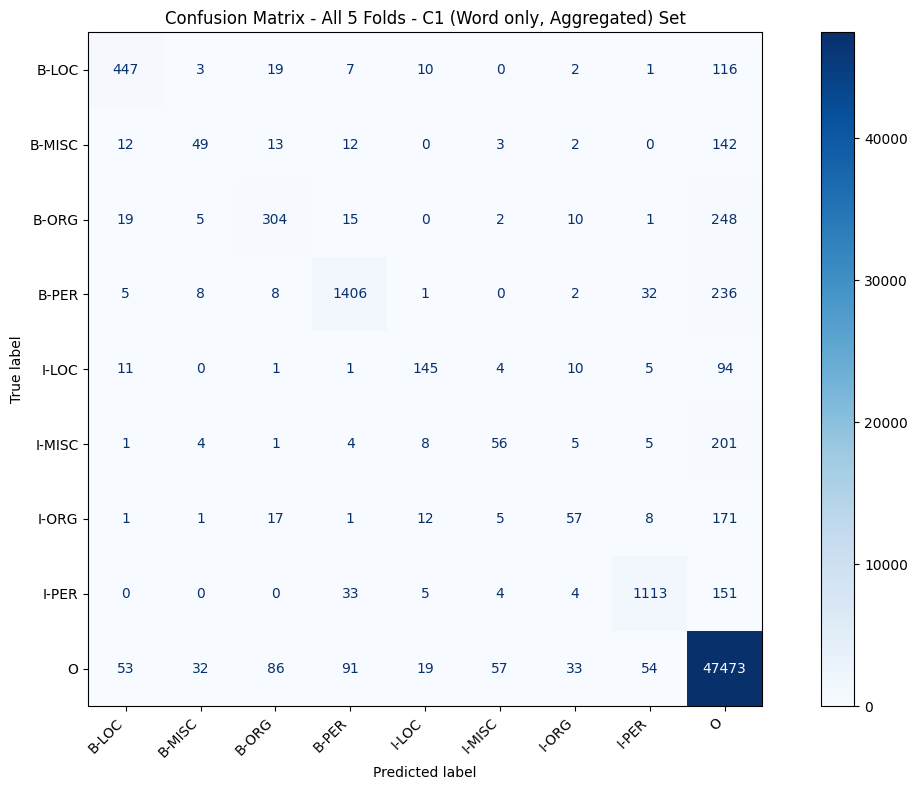

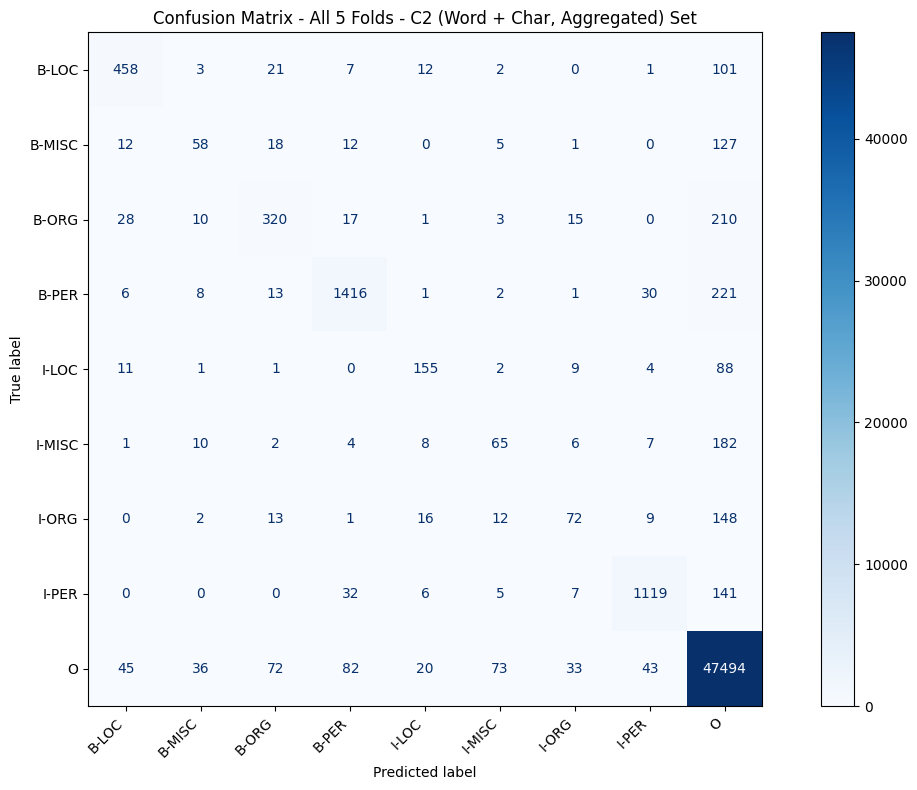


METHOD C COMPLETE: C2 selected as representative model

Method C Summary:
   C1 (Word embeddings): F1 = 0.6996 ± 0.0148
   C2 (Word + Char): F1 = 0.7189 ± 0.0124
   Best variant: C2


In [26]:
#AGGREGATE RESULTS AND SELECT BEST METHOD
print("AGGREGATE RESULTS & SELECT BEST METHOD C\n" + "="*70)

# Calculate mean metrics for C1
mean_precision_C1 = np.mean(fold_scores_C1['precision'])
mean_recall_C1 = np.mean(fold_scores_C1['recall'])
mean_f1_C1 = np.mean(fold_scores_C1['f1'])
std_f1_C1 = np.std(fold_scores_C1['f1'])

# Calculate mean metrics for C2
mean_precision_C2 = np.mean(fold_scores_C2['precision'])
mean_recall_C2 = np.mean(fold_scores_C2['recall'])
mean_f1_C2 = np.mean(fold_scores_C2['f1'])
std_f1_C2 = np.std(fold_scores_C2['f1'])

# Compare C1 vs C2
f1_diff_C = mean_f1_C2 - mean_f1_C1
f1_threshold = 0.001

print("\n" + "="*70)
print("FOLD-BY-FOLD RESULTS (METHOD C)")
print("="*70)

# Display per-fold results
results_data = []
for fold_idx in range(K_FOLDS):
    results_data.append({
        'Fold': fold_idx + 1,
        'C1 F1': f"{fold_scores_C1['f1'][fold_idx]:.4f}",
        'C2 F1': f"{fold_scores_C2['f1'][fold_idx]:.4f}",
        'Diff': f"{fold_scores_C2['f1'][fold_idx] - fold_scores_C1['f1'][fold_idx]:.4f}",
        'Winner': 'C2' if fold_scores_C2['f1'][fold_idx] > fold_scores_C1['f1'][fold_idx] else 'C1'
    })

results_df = pd.DataFrame(results_data)
print("\n", results_df.to_string(index=False))

print("\n" + "="*70)
print("AVERAGE METRICS ACROSS 5 FOLDS (METHOD C)")
print("="*70)

# Create summary table
summary_data = {
    'Model': ['C1 (Word only)', 'C2 (Word + Char)'],
    'Precision': [f"{mean_precision_C1:.4f}", f"{mean_precision_C2:.4f}"],
    'Recall': [f"{mean_recall_C1:.4f}", f"{mean_recall_C2:.4f}"],
    'F1-Score': [f"{mean_f1_C1:.4f} ± {std_f1_C1:.4f}", f"{mean_f1_C2:.4f} ± {std_f1_C2:.4f}"]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Decision logic
print("\n" + "="*70)
print("DECISION: SELECT BEST METHOD C")
print("="*70)

print(f"\nF1 Difference (C2 - C1): {f1_diff_C:.6f}")
print(f"Threshold: {f1_threshold}")

if abs(f1_diff_C) <= f1_threshold:
    best_C = 'C1'
    reason = f"Difference {abs(f1_diff_C):.6f} ≤ threshold {f1_threshold} -> Choose simpler model (C1)"
else:
    if f1_diff_C > 0:
        best_C = 'C2'
        reason = f"C2 better by {f1_diff_C:.6f} > threshold {f1_threshold}"
    else:
        best_C = 'C1'
        reason = f"C1 better by {abs(f1_diff_C):.6f} > threshold {f1_threshold}"

print(f"\nSELECTED: {best_C} (Mean F1: {max(mean_f1_C1, mean_f1_C2):.4f})")
print(f"  Reason: {reason}")

# Store best Method C results
best_method_C = best_C
best_scores_C = {
    'precision': mean_precision_C2 if best_C == 'C2' else mean_precision_C1,
    'recall': mean_recall_C2 if best_C == 'C2' else mean_recall_C1,
    'f1': mean_f1_C2 if best_C == 'C2' else mean_f1_C1,
    'std_f1': std_f1_C2 if best_C == 'C2' else std_f1_C1
}

# PLOT CONFUSION MATRICES FOR BEST METHOD C (AGGREGATED ACROSS ALL FOLDS)
print(f"\n{'='*70}")
print("PLOTTING CONFUSION MATRICES (ALL 5 FOLDS - Aggregated)")
print(f"{'='*70}\n")

# Concatenate predictions from all 5 folds
y_val_C1_all = []
y_pred_C1_all = []
y_val_C2_all = []
y_pred_C2_all = []

for fold_idx in range(K_FOLDS):
    fold_pred = all_fold_predictions_C[fold_idx]
    y_val_C1_all.extend(fold_pred['y_val_C1'])
    y_pred_C1_all.extend(fold_pred['y_pred_C1'])
    y_val_C2_all.extend(fold_pred['y_val_C2'])
    y_pred_C2_all.extend(fold_pred['y_pred_C2'])

# Plot confusion matrix for C1 (aggregated)
plot_confusion_matrix(y_val_C1_all, y_pred_C1_all, set_name="All 5 Folds - C1 (Word only, Aggregated)")

# Plot confusion matrix for C2 (aggregated)
plot_confusion_matrix(y_val_C2_all, y_pred_C2_all, set_name="All 5 Folds - C2 (Word + Char, Aggregated)")

print(f"\n{'='*70}")
print(f"METHOD C COMPLETE: {best_C} selected as representative model")
print(f"{'='*70}\n")

print("Method C Summary:")
print(f"   C1 (Word embeddings): F1 = {mean_f1_C1:.4f} ± {std_f1_C1:.4f}")
print(f"   C2 (Word + Char): F1 = {mean_f1_C2:.4f} ± {std_f1_C2:.4f}")
print(f"   Best variant: {best_C}")

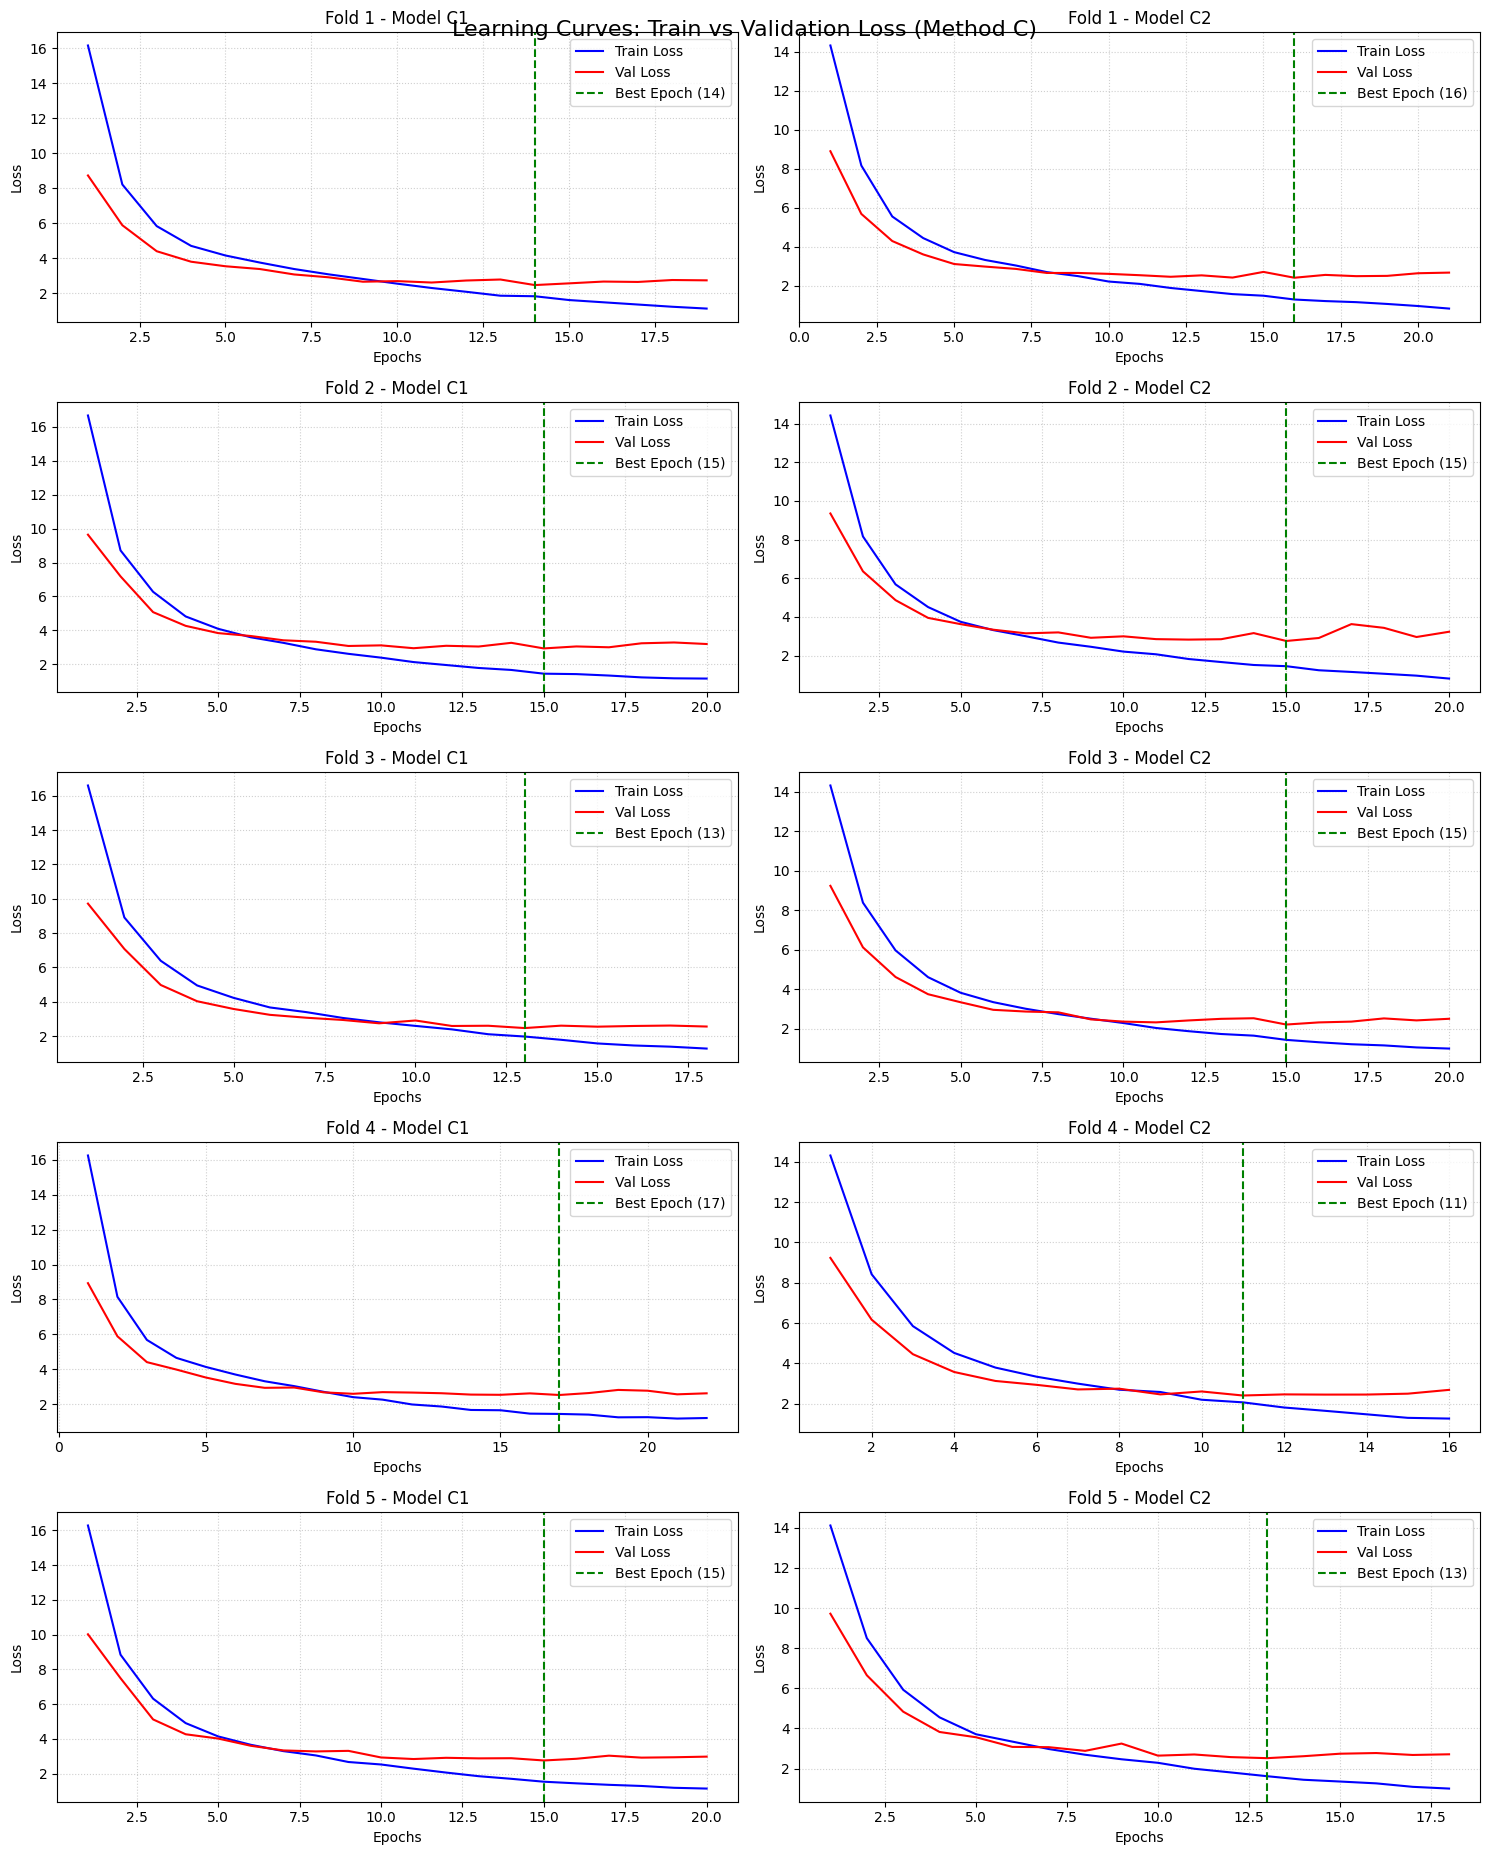

In [27]:
#Determine the convergence of C1 and C2 to evaluate the model.
import matplotlib.pyplot as plt

# Create figure vwith  5 row (5 fold) và 2 columns (C1 and C2)
fig, axes = plt.subplots(K_FOLDS, 2, figsize=(15, 4 * K_FOLDS))
fig.suptitle('Learning Curves: Train vs Validation Loss (Method C)', fontsize=16, y=0.92)

for fold_idx in range(K_FOLDS):
    # Chart for Model C1
    ax1 = axes[fold_idx, 0]
    hist_c1 = fold_training_history[fold_idx]['C1']
    epochs_c1 = range(1, len(hist_c1['train_loss']) + 1)
    
    ax1.plot(epochs_c1, hist_c1['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs_c1, hist_c1['val_loss'], 'r-', label='Val Loss')
    # Đánh dấu epoch tốt nhất với đường nét đứt
    ax1.axvline(x=hist_c1['best_epoch'] + 1, color='g', linestyle='--', 
                label=f'Best Epoch ({hist_c1["best_epoch"] + 1})')
    
    ax1.set_title(f'Fold {fold_idx + 1} - Model C1')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Chart for Model C2
    ax2 = axes[fold_idx, 1]
    hist_c2 = fold_training_history[fold_idx]['C2']
    epochs_c2 = range(1, len(hist_c2['train_loss']) + 1)
    
    ax2.plot(epochs_c2, hist_c2['train_loss'], 'b-', label='Train Loss')
    ax2.plot(epochs_c2, hist_c2['val_loss'], 'r-', label='Val Loss')
    ax2.axvline(x=hist_c2['best_epoch'] + 1, color='g', linestyle='--', 
                label=f'Best Epoch ({hist_c2["best_epoch"] + 1})')
    
    ax2.set_title(f'Fold {fold_idx + 1} - Model C2')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

FINAL EVALUATION WITH TEST SET AND GROUTH TRUTH (METHOD A2, B, C2)

In [28]:
print("="*70)
print("FINAL EVALUATION ON OFFICIAL TEST SET (METHODS A, B, C)")
print("="*70)

import os
import pandas as pd
import re
from seqeval.scheme import IOB2

# LOAD RAW DATA AND GROUND TRUTH
DATA_DIR = "data"
TEST_PATH = os.path.join(DATA_DIR, "TweetsTestset.txt")
GT_PATH = os.path.join(DATA_DIR, "TweetsTestGroundTruth.txt")

raw_test_df = pd.read_csv(TEST_PATH, sep="\t", header=None)
gt_test_df = pd.read_csv(GT_PATH, sep="\t", header=None)

# Merge again using column ID (column 0) to map tweets to their correct entities.
official_test_df = raw_test_df.merge(gt_test_df[[0, 1]], on=0, how='inner')
official_test_df.columns = ['id', 'text', 'entities']

# DEFINE PREPROCESSING FUNCTION
def build_test_sequences(df, text_col, entities_col=None):
    rows = []
    for _, row in df.iterrows():
        text = row[text_col]

        # Tokenization Regex
        tokens_pos = []
        for match in re.finditer(pattern, text):
            token = match.group()
            tokens_pos.append((match.start(), match.end(), token))

        raw_tokens = [t for _, _, t in tokens_pos]
        mapped_tokens = [get_mapped_word(t) for t in raw_tokens] # Mapping _URL_, _HASHTAG_, _MENTION_
        tags = None

        # BIO Tagging If a column for entities (Ground Truth) is provided.
        if entities_col is not None:
            entities = parse_entities(row[entities_col])
            entity_spans = find_entities(text, entities)
            tags = get_bio_tags(raw_tokens, tokens_pos, entity_spans)

            # Force the tags of MENTION, HASHTAG, URL to "O"
            for i, mt in enumerate(mapped_tokens):
                if mt in ['_MENTION_', '_HASHTAG_', '_URL_']:
                    tags[i] = 'O'

        rows.append({
            'id': row['id'],
            'tokens': mapped_tokens,
            'tags': tags,
            'text': text
        })

    return pd.DataFrame(rows)


# RETRIEVE ALL TRAIN DATA FOR RETRAINING
print("Extracting full training tokens and tags...")
final_train_tokens = sequences_df['tokens'].tolist()
final_train_tags = sequences_df['tags'].tolist()
print(f"Total training sequences: {len(final_train_tokens)}")


# CREATE TESTING SEQUENCES (Input & Target Labels) 
print("\nBuilding tokens and extracting labels for testing...")

# Create a DataFrame to separate the blind test data (for the model) and the answers (for scoring).
test_sequences_df = build_test_sequences(official_test_df, text_col='text', entities_col=None)
gold_sequences_df = build_test_sequences(official_test_df, text_col='text', entities_col='entities')

# EXTRACT THE MOST IMPORTANT VARIABLES TO BE USED IN THE NEXT CELLS:
test_tokens = test_sequences_df['tokens'].tolist()       # <-- Input for model predict (List of lists)
y_test_true = gold_sequences_df['tags'].tolist()         # <-- Target actual BIO tags for evaluation

print(f"Loaded {len(test_tokens)} testing sequences.")
print("Preprocessing complete! Testing Data is ready.")

FINAL EVALUATION ON OFFICIAL TEST SET (METHODS A, B, C)
Extracting full training tokens and tags...
Total training sequences: 2815

Building tokens and extracting labels for testing...
Loaded 1450 testing sequences.
Preprocessing complete! Testing Data is ready.



EVALUATING METHOD A (A2) ON TEST SET
Best hyperparameters found in Fold 3 (F1: 0.6925)

Extracting features for Full Train Set & Test Set using A2 function...

Retraining the best CRF model on the FULL Training Dataset...
Retraining completed!

Predicting BIO tags for Test Set...

--- Method A (A2) Results on Official Test Set ---
              precision    recall  f1-score   support

         LOC       0.42      0.36      0.39        97
        MISC       0.31      0.12      0.18        90
         ORG       0.54      0.26      0.35       231
         PER       0.85      0.74      0.80      1126

   micro avg       0.78      0.61      0.69      1544
   macro avg       0.53      0.37      0.43      1544
weighted avg       0.75      0.61      0.67      1544

Test F1-score for Method A: 0.6858

Plotting Confusion Matrix for Method A...


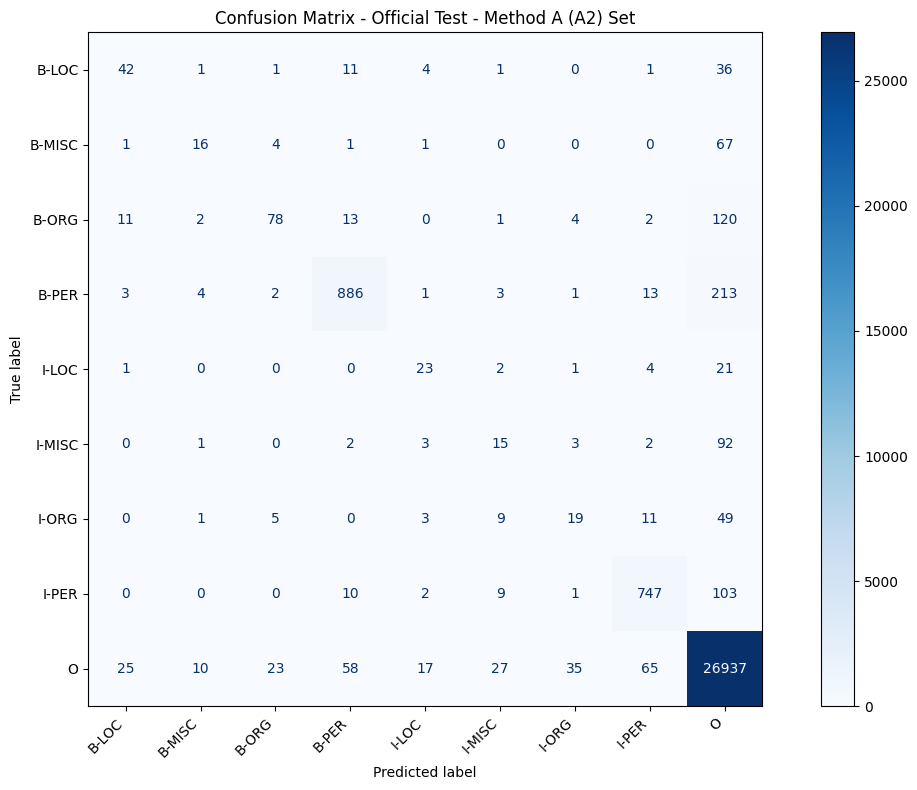

In [29]:
# FINAL EVALUATION - METHOD A (CRF)
import numpy as np
from sklearn.base import clone
from seqeval.metrics import classification_report, f1_score

print("\n" + "="*70)
print(f"EVALUATING METHOD A ({best_method_A}) ON TEST SET")
print("="*70)

# Identify the Fold with the best Hyperparameters (c1, c2) during Cross Validation.
if best_method_A == 'A1':
    best_fold_idx = np.argmax(fold_scores_A1['f1'])
    best_val_f1 = fold_scores_A1['f1'][best_fold_idx]
else:
    best_fold_idx = np.argmax(fold_scores_A2['f1'])
    best_val_f1 = fold_scores_A2['f1'][best_fold_idx]

print(f"Best hyperparameters found in Fold {best_fold_idx + 1} (F1: {best_val_f1:.4f})")
best_cv_model = best_models_per_fold[best_method_A][best_fold_idx]

# Extract Features for ALL Training and Test Sets
print(f"\nExtracting features for Full Train Set & Test Set using {best_method_A} function...")
if best_method_A == 'A1':
    X_train_final_A = [sent2features_A1(tokens) for tokens in final_train_tokens]
    X_test_A = [sent2features_A1(tokens) for tokens in test_tokens]
else:
    X_train_final_A = [sent2features_A2(tokens) for tokens in final_train_tokens]
    X_test_A = [sent2features_A2(tokens) for tokens in test_tokens]

# Clone (Create a new copy) of the best CRF model configuration (empty, not yet fitted)
# sklearn.base.clone will copy all parameters (such as c1, c2, algorithm) exactly but reset all weights to their initial state. This allows us to retrain from scratch on the full dataset while keeping the same hyperparameters.
final_crf_model = clone(best_cv_model)

# Retrain the model across the entire dataset
print("\nRetraining the best CRF model on the FULL Training Dataset...")
final_crf_model.fit(X_train_final_A, final_train_tags)
print("Retraining completed!")

# Inference on the official test set
print("\nPredicting BIO tags for Test Set...")
y_test_pred_A = final_crf_model.predict(X_test_A)

# Evaluate the results using seqeval
print(f"\n--- Method A ({best_method_A}) Results on Official Test Set ---")
print(classification_report(y_test_true, y_test_pred_A, mode='strict', scheme=IOB2))

# Save the F1 score
f1_test_A = f1_score(y_test_true, y_test_pred_A, mode='strict', scheme=IOB2)
print(f"Test F1-score for Method A: {f1_test_A:.4f}")

# Plot Confusion Matrix
print("\nPlotting Confusion Matrix for Method A...")
plot_confusion_matrix(y_test_true, y_test_pred_A, set_name=f"Official Test - Method A ({best_method_A})")


----------------------------------------------------------------------
TESTING METHOD B (HMM)
Length mismatches: 0

Evaluation Results for Official Test - Method B Set
----------------------------------------------------------------------
Precision (Micro): 0.5894
Recall (Micro):    0.5269
F1-Score (Micro):  0.5564

Classification Report:
              precision    recall  f1-score   support

         LOC       0.36      0.24      0.29        97
        MISC       0.21      0.12      0.15        90
         ORG       0.43      0.21      0.28       232
         PER       0.64      0.65      0.64      1126

   micro avg       0.59      0.53      0.56      1545
   macro avg       0.41      0.30      0.34      1545
weighted avg       0.56      0.53      0.54      1545



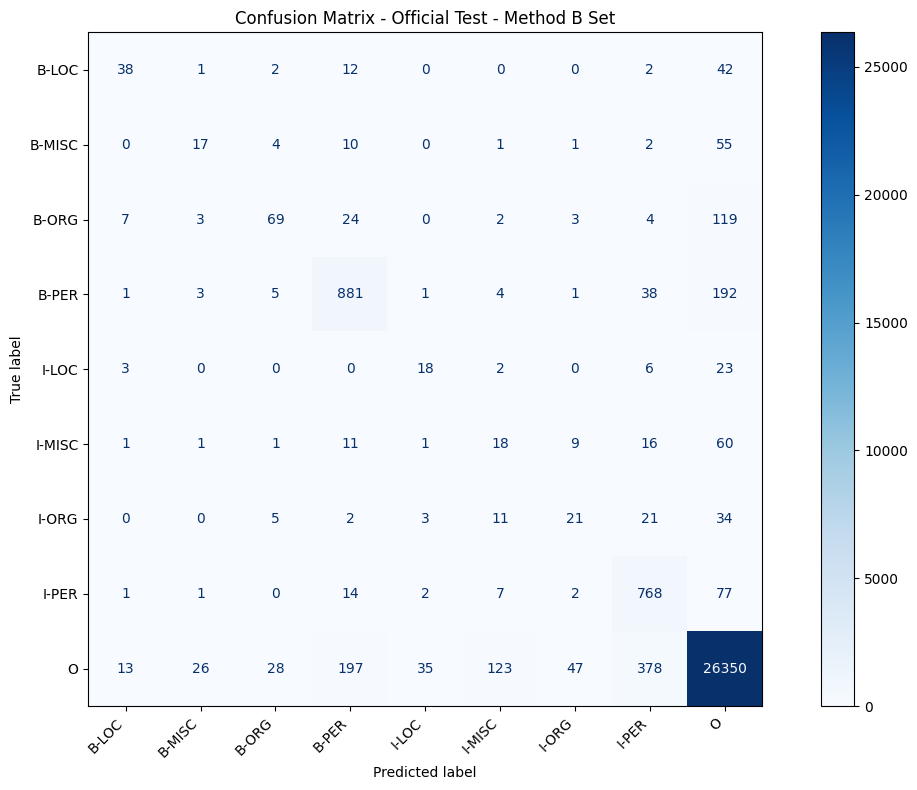


Official test evaluation for Method B complete.


In [30]:
# FINAL EVALUATION - METHOD B (HMM)
print("\n" + "-"*70 + "\nTESTING METHOD B (HMM)")

final_hmm = HMMNER(
    alpha_trans=BEST_ALPHA_TRANS,
    alpha_emit=BEST_ALPHA_EMIT,
    rare_threshold=BEST_RARE_THRESHOLD,
    use_bio_constraints=True
)
final_hmm.fit(final_train_tokens, final_train_tags)

y_test_pred_B = final_hmm.predict(test_sequences_df['tokens'].tolist())
y_test_true = gold_sequences_df['tags'].tolist()

# Safety check
mismatches = [i for i, (yt, yp) in enumerate(zip(y_test_true, y_test_pred_B)) if len(yt) != len(yp)]
print("Length mismatches:", len(mismatches))

# Pass y_test_pred_B into the evaluation function
final_test_metrics_B = evaluate_ner(y_test_true, y_test_pred_B, set_name="Official Test - Method B")
plot_confusion_matrix(y_test_true, y_test_pred_B, set_name="Official Test - Method B")

print("\nOfficial test evaluation for Method B complete.")


EVALUATING METHOD C (C2) ON TEST SET
Initializing fresh C2 model for Full Retrain...

Creating Dataset & DataLoader for FULL Training Set...
Retraining Method C2 from scratch for 15 epochs...
  Epoch  1/15 | Train Loss: 13.8848
  Epoch  2/15 | Train Loss: 9.2085
  Epoch  3/15 | Train Loss: 7.1426
  Epoch  4/15 | Train Loss: 5.3884
  Epoch  5/15 | Train Loss: 4.4127
  Epoch  6/15 | Train Loss: 3.7658
  Epoch  7/15 | Train Loss: 3.3987
  Epoch  8/15 | Train Loss: 3.0723
  Epoch  9/15 | Train Loss: 2.7685
  Epoch 10/15 | Train Loss: 2.5967
  Epoch 11/15 | Train Loss: 2.3366
  Epoch 12/15 | Train Loss: 2.1083
  Epoch 13/15 | Train Loss: 1.9146
  Epoch 14/15 | Train Loss: 1.7977
  Epoch 15/15 | Train Loss: 1.6609
Retraining completed!

Creating Dataset & DataLoader for Official Test Set...
Predicting BIO tags for Test Set...

--- Method C (C2) Results on Official Test Set ---
              precision    recall  f1-score   support

         LOC       0.57      0.30      0.39        97
      

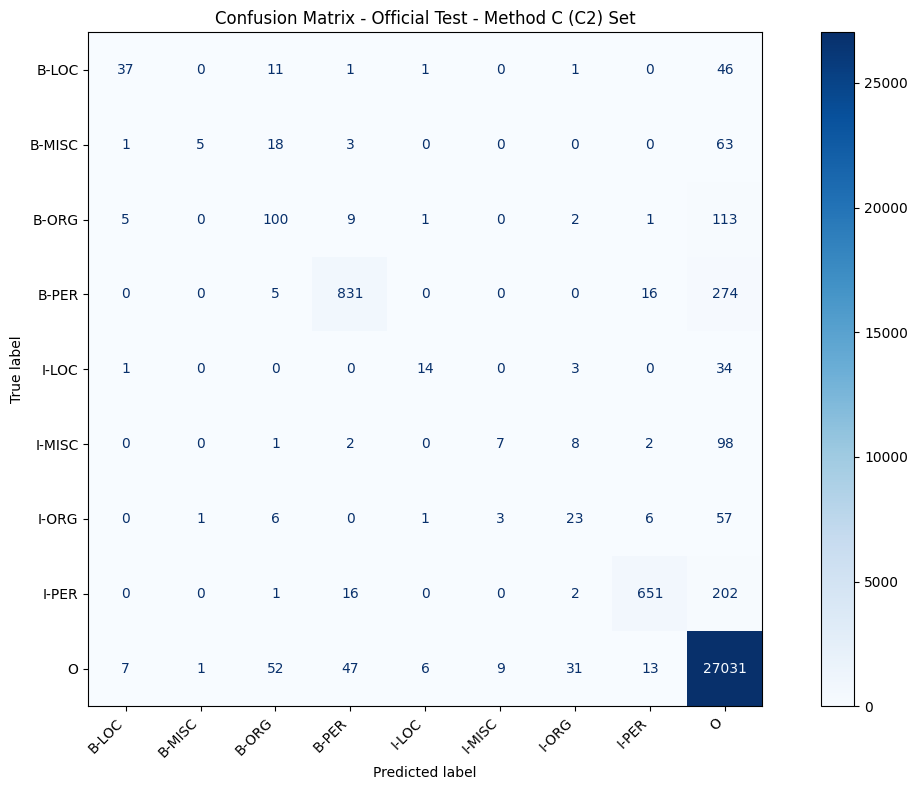

In [31]:
# FINAL EVALUATION - METHOD C (BiLSTM-CRF)
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from seqeval.metrics import classification_report, f1_score

print("\n" + "="*70)
print(f"EVALUATING METHOD C ({best_method_C}) ON TEST SET")
print("="*70)


print(f"Initializing fresh {best_method_C} model for Full Retrain...")
if best_method_C == 'C1':
    final_model_C = BiLSTM_C1(
        vocab_size=len(token2id),
        tag_size=len(tag2id),
        embedding_dim = EMBEDDING_DIM,
        hidden_dim = HIDDEN_DIM,
        embedding_matrix=embedding_matrix,
        num_layers=2,
        dropout=0.4,
        bidirectional=True
    ).to(device)
else: 
    final_model_C = BiLSTM_C2(
        vocab_size=len(token2id), 
        tag_size=len(tag2id), 
        embedding_dim = EMBEDDING_DIM, 
        char_vocab_size=len(char2id), 
        char_embedding_dim = CHAR_EMBEDDING_DIM,
        char_conv_filters = CHAR_CONV_FILTERS, 
        char_conv_kernel = CHAR_CONV_KERNEL, 
        hidden_dim = HIDDEN_DIM, 
        embedding_matrix=embedding_matrix,
        num_layers=2,
        dropout=0.4,
        bidirectional=True
    ).to(device)

# Optimizer and DataLoader for full training set
optimizer_C = optim.Adam(final_model_C.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print("\nCreating Dataset & DataLoader for FULL Training Set...")
full_train_dataset = NERDataset(final_train_tokens, final_train_tags, token2id, tag2id, char2id)
full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

# RETRAIN LOOP on FULL TRAIN
RETRAIN_EPOCHS = 15
print(f"Retraining Method {best_method_C} from scratch for {RETRAIN_EPOCHS} epochs...")

final_model_C.train()
for epoch in range(RETRAIN_EPOCHS):
    total_loss = 0
    for batch in full_train_loader:
        token_ids = batch['token_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tag_ids = batch['tag_ids'].to(device)
        seq_lens = batch['seq_lens'].to(device)
        
        optimizer_C.zero_grad()
        
        # Build logic forward tuỳ cấu trúc
        if best_method_C == 'C1':
            loss = final_model_C(token_ids, attention_mask, tag_ids=tag_ids, seq_lens=seq_lens)
        else:
            char_ids = batch['char_ids'].to(device)
            loss = final_model_C(token_ids, char_ids, attention_mask, tag_ids=tag_ids, seq_lens=seq_lens)
            
        loss.backward()
        optimizer_C.step()
        total_loss += loss.item()
        
    print(f"  Epoch {epoch+1:2d}/{RETRAIN_EPOCHS} | Train Loss: {total_loss/len(full_train_loader):.4f}")

print("Retraining completed!")

# Inference Loop on OFFICIAL TEST
print("\nCreating Dataset & DataLoader for Official Test Set...")
test_dataset = NERDataset(test_tokens, y_test_true, token2id, tag2id, char2id)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("Predicting BIO tags for Test Set...")
final_model_C.eval()
y_test_pred_C = []

with torch.no_grad():
    for batch in test_loader:
        token_ids = batch['token_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        seq_lens = batch['seq_lens'].to(device)
        
        # Forward inference 
        if best_method_C == 'C1':
            predictions = final_model_C(token_ids, attention_mask, tag_ids=None, seq_lens=seq_lens)
        else:
            char_ids = batch['char_ids'].to(device)
            predictions = final_model_C(token_ids, char_ids, attention_mask, tag_ids=None, seq_lens=seq_lens)
            
        # Decode list tensor -> tag texts
        for i, seq_pred in enumerate(predictions):
            seq_length = seq_lens[i].item()
            pred_tags = []
            for tag_id in seq_pred[:seq_length]:
                token_tag_val = tag_id.item() if isinstance(tag_id, torch.Tensor) else tag_id
                pred_tags.append(id2tag[token_tag_val])
                
            y_test_pred_C.append(pred_tags)

#Final Evaluation with Seqeval
print(f"\n--- Method C ({best_method_C}) Results on Official Test Set ---")
print(classification_report(y_test_true, y_test_pred_C, mode='strict', scheme=IOB2))

f1_test_C = f1_score(y_test_true, y_test_pred_C, mode='strict', scheme=IOB2)
print(f"Test F1-score for Method C: {f1_test_C:.4f}")

# Confusion Matrix
plot_confusion_matrix(y_test_true, y_test_pred_C, set_name=f"Official Test - Method C ({best_method_C})")